In [18]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.interpolate import griddata
from tabulate import tabulate
from skimage.metrics import structural_similarity as ssim

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


batch_size = 512
learning_rate = 0.001
num_epochs = 10000

In [19]:
import matplotlib as mpl

def set_plot_params():
    """
    Matplotlib's rcParams for consistent, publication-quality plots.
    """
    ## Figure settings
    mpl.rcParams['figure.figsize'] = (8, 6)       # Figure size in inches
    mpl.rcParams['figure.dpi'] = 100              # (Display) Figure resolution
    mpl.rcParams['savefig.dpi'] = 300             # Resolution when saving figures

    ## Font settings (Standard 16-14-12 config.)
    mpl.rcParams['font.family'] = 'serif'         # Serif fonts
    mpl.rcParams['font.size'] = 12                # Base font size
    mpl.rcParams['axes.titlesize'] = 16           # Title font size for axes
    mpl.rcParams['axes.labelsize'] = 14           # Font size for x and y labels
    mpl.rcParams['xtick.labelsize'] = 12          # Font size for x-tick labels
    mpl.rcParams['ytick.labelsize'] = 12          # Font size for y-tick labels
    mpl.rcParams['legend.fontsize'] = 12          # Legend font size

    ## Line settings
    mpl.rcParams['lines.linewidth'] = 2           # Default line width
    mpl.rcParams['lines.markersize'] = 6          # Marker size for plots

    ## Contour plot settings
    mpl.rcParams['contour.negative_linestyle'] = 'solid'

    ## Grid settings
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    ## Color presets (Plasma-ish color scheme)
    mpl.rcParams['image.cmap'] = 'plasma' # Can be changed to "jet", "viridis", etc.

    ## Default color cycle for line plots using the plasma colormap.
    plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.
    num_colors = 10
    colors = [plasma_cmap(i) for i in np.linspace(0, 1, num_colors)]
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

In [20]:
def compute_mae(S_exact, S_approx):
    return np.mean(np.abs(S_exact - S_approx))

In [21]:
def compute_fourier_mse(S_exact, S_approx):
    F_exact = np.fft.fft2(S_exact)
    F_approx = np.fft.fft2(S_approx)
    return np.mean(np.abs(F_exact - F_approx) ** 2)

In [22]:
def relative_l2_error(original: np.ndarray, approx: np.ndarray) -> float:

    return np.linalg.norm(original - approx, 'fro') / np.linalg.norm(original, 'fro')

def compute_error_stats(original: np.ndarray, approx: np.ndarray):

    errors = relative_l2_error(original, approx)

    return np.mean(errors)

In [23]:
def compute_psnr(original, compressed):

    assert original.shape == compressed.shape, "Matrices must have the same shape."

    mse = np.mean((original - compressed) ** 2)
    if mse == 0:  # Perfect match
        return float('inf')

    max_pixel = np.max(original)
    psnr = 10 * np.log10((max_pixel ** 2) / mse)

    return psnr

In [24]:
def compute_mse(matrix1, matrix2):

    assert matrix1.shape == matrix2.shape, "Matrices must have the same shape."

    mse = np.sum((matrix1 - matrix2) ** 2) / matrix1.size

    return mse

In [25]:
def compute_ssim(matrix1, matrix2):

  if matrix1.shape != matrix2.shape:
    raise ValueError("Matrices must have the same dimensions")

  ssim_value = ssim(matrix1, matrix2, data_range=matrix2.max() - matrix2.min())

  return ssim_value

In [26]:
data = np.load('Kuramoto_Sivashinsky_dataset_sine_initialization_4_random_terms.npz')
u_train = data['u_train']
s_train = data['s_train']

In [27]:
s_train = s_train[:,:,0:224]
print(u_train.shape)
print(s_train.shape)

(10000, 128, 1)
(10000, 128, 224)


1824


C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


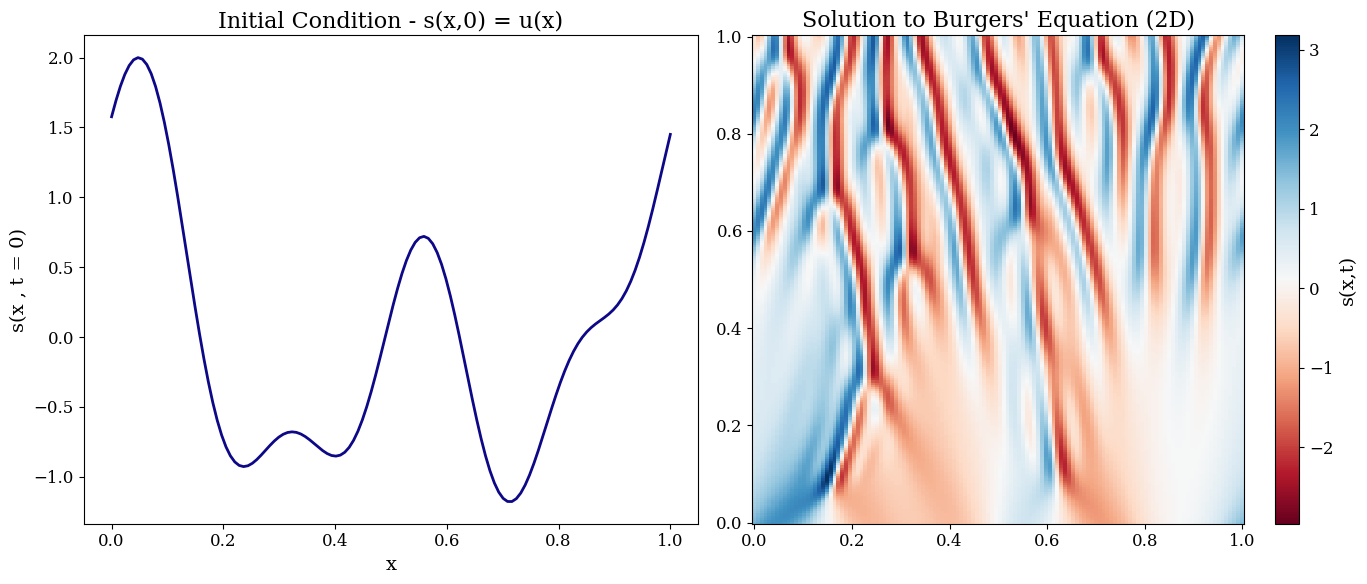

In [28]:
sample_idx = random.randint(0, u_train.shape[0])
print(sample_idx)
# Limits on graph plotting
xmin, xmax = 0, 1
tmin, tmax = 0, 1
x = np.linspace(xmin, xmax, 128)
t = np.linspace(tmin, tmax, 224)
XX, TT = np.meshgrid(x,t)


# Initial Condition and Full Solution Plots
set_plot_params()
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121)
plt.plot(x,u_train[sample_idx])
plt.xlabel('x')
plt.ylabel('s(x , t = 0)')
plt.title('Initial Condition - s(x,0) = u(x)')
ax2 = fig.add_subplot(122)
c = ax2.pcolor( XX, TT, s_train[sample_idx].T, cmap='RdBu')
ax2.set_title('Solution to Burgers\' Equation (2D)')
fig.colorbar(c, ax=ax2, label='s(x,t)')


plt.tight_layout()
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    u_train, s_train, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 128, 1), (2000, 128, 1), (8000, 128, 224), (2000, 128, 224))

In [30]:
class Burgers_1D_Dataset(Dataset):

    def __init__(self, initial_condition, full_solution):

        self.initial_condition = torch.tensor(initial_condition, dtype=torch.float32)
        self.full_solution = torch.tensor(full_solution, dtype=torch.float32)
        self.grid_size_x = 128
        self.grid_size_t = 224
        grid_x = np.linspace(0, 1, self.grid_size_x)
        grid_t = np.linspace(0, 1, self.grid_size_t)
        self.X, self.Y = np.meshgrid(grid_x, grid_t)
        self.coords = np.stack([self.X, self.Y], axis=-1)
        self.coords = torch.tensor(self.coords, dtype=torch.float32)

    def __len__(self):
        return self.initial_condition.shape[0]

    def __getitem__(self, idx):
        initial_condition = self.initial_condition[idx]
        full_solution = self.full_solution[idx]
        return initial_condition, full_solution

In [31]:
# Trunk Net Model
class FourierEmbedding(nn.Module):

    # Fourier Feature Mapping
    def __init__(self, input_dim, mapping_size=512):
        super().__init__()
        self.B = torch.randn(input_dim, mapping_size) * 10.0

    def forward(self, x):
        x_proj = 2 * np.pi * x @ self.B.to(x.device)
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class TrunkNet(nn.Module):

    # Based on the Fourier Embedding defined above
    def __init__(self, input_dim):
        super().__init__()
        self.fourier_embed = FourierEmbedding(input_dim)
        self.fc = nn.Sequential(
            nn.Linear(512*2, 256*2),
            nn.ReLU(),
            nn.Linear(256*2, 128*2),
            nn.ReLU(),
            nn.Linear(128*2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
        )

    def forward(self, x):
        x = self.fourier_embed(x)
        return self.fc(x)

class BranchNet(nn.Module):
    def __init__(self):
        super(BranchNet, self).__init__()
        self.linear_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
        )

    def forward(self, x):
        return self.linear_layers(x)

class DeepONet(nn.Module):
    def __init__(self):
        super(DeepONet, self).__init__()

        self.branch_net = BranchNet()
        self.trunk_net = TrunkNet(input_dim = 2)

    def forward(self, initial_condition, coords):

        batch_size = initial_condition.size(0)
        grid_size_x = coords.size(0)
        grid_size_t = coords.size(1)
        coords_flat = coords.view(-1, 2)
        trunk_out = self.trunk_net(coords_flat)
        branch_out = self.branch_net(initial_condition)
        outputs = torch.matmul(branch_out, trunk_out.T)
        outputs = outputs.view(batch_size, grid_size_t, grid_size_x)

        return outputs
    
    

In [32]:
## Train Hyperparameter
train_dataset = Burgers_1D_Dataset(X_train, y_train)
test_dataset = Burgers_1D_Dataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepONet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100, verbose=True)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda epoch: 0.9 ** (epoch / 2000))
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, total_steps=num_epochs)


device


device(type='cuda')

In [33]:

## Train function

def train(model, loader, optimizer, criterion, device, coords):

    model.train()
    running_loss = 0.0

    for initial_condition, full_solution in loader:

        initial_condition = initial_condition.to(device)
        full_solution = full_solution.to(device)
        optimizer.zero_grad()
        outputs = model(initial_condition, coords.to(device))
        loss = criterion(outputs, full_solution)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * initial_condition.size(0)


    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss

# Evaluation function
def evaluate(model, loader, criterion, device, coords):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for initial_condition, full_solution in loader:

            initial_condition = initial_condition.to(device)
            full_solution = full_solution.to(device)
            outputs = model(initial_condition, coords.to(device))
            loss = criterion(outputs, full_solution)
            running_loss += loss.item() * initial_condition.size(0)

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss


In [ ]:
# Training Loop
train_losses_fourier = []
test_losses_fourier = []

coords = train_dataset.coords.to(device)

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device, coords)
    test_loss = evaluate(model, test_loader, criterion, device, coords)

    train_losses_fourier.append(train_loss)
    test_losses_fourier.append(test_loss)
    
    # Step the scheduler
    # scheduler.step()  # For StepLR
    scheduler.step()  # Uncomment if using ReduceLROnPlateau

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.12f}, '
          f'Test Loss: {test_loss:.12f}, '
          f'LR: {optimizer.param_groups[0]["lr"]:.6f}')


C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


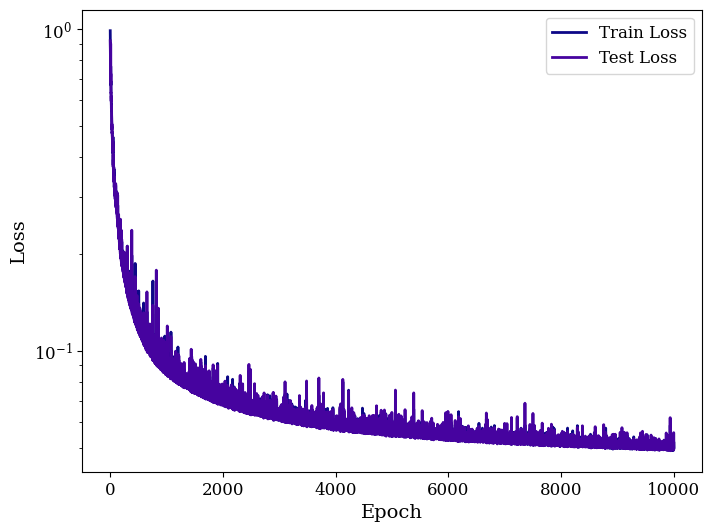

In [35]:

plt.figure()
set_plot_params()
plt.semilogy(range(1, num_epochs+1), train_losses_fourier, label='Train Loss')
plt.semilogy(range(1, num_epochs+1), test_losses_fourier, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [36]:
# Normal DeepONet with Linear Layers
class BranchNet_normal(nn.Module):
    def __init__(self):
        super(BranchNet_normal, self).__init__()
        self.linear_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
        )

    def forward(self, x):
        return self.linear_layers(x)

class TrunkNet_normal(nn.Module):
    def __init__(self):
        super(TrunkNet_normal, self).__init__()
        self.fc_layers = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
        )

    def forward(self, coords):
        coords = coords.view(-1, 2)
        return self.fc_layers(coords)


class DeepONet_normal(nn.Module):
    def __init__(self):
        super(DeepONet_normal, self).__init__()

        self.branch_net_normal = BranchNet_normal()
        self.trunk_net_normal = TrunkNet_normal()

    def forward(self, initial_condition, coords):
        
        batch_size = initial_condition.size(0)
        grid_size_x = coords.size(0)
        grid_size_t = coords.size(1)
        coords_flat = coords.view(-1, 2)
        trunk_out_normal = self.trunk_net_normal(coords_flat)
        branch_out_normal = self.branch_net_normal(initial_condition)
        outputs = torch.matmul(branch_out_normal, trunk_out_normal.T)
        outputs = outputs.view(batch_size, grid_size_t, grid_size_x)

        return outputs


In [37]:
## Train Hyperparameters

batch_size = 512
learning_rate = 0.001
num_epochs = 10000

train_dataset = Burgers_1D_Dataset(X_train, y_train)
test_dataset = Burgers_1D_Dataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_normal = DeepONet_normal().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_normal.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda epoch: 0.9 ** (epoch / 2000))
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100, verbose=True)

In [ ]:
# Training Loop
train_losses = []
test_losses = []

coords = train_dataset.coords.to(device)

for epoch in range(num_epochs):
    train_loss = train(model_normal, train_loader, optimizer, criterion, device, coords)
    test_loss = evaluate(model_normal, test_loader, criterion, device, coords)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # Step the scheduler
    # scheduler.step()  # For StepLR
    scheduler.step()  # Uncomment if using ReduceLROnPlateau

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.12f}, '
          f'Test Loss: {test_loss:.12f}, '
          f'LR: {optimizer.param_groups[0]["lr"]:.6f}')


C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


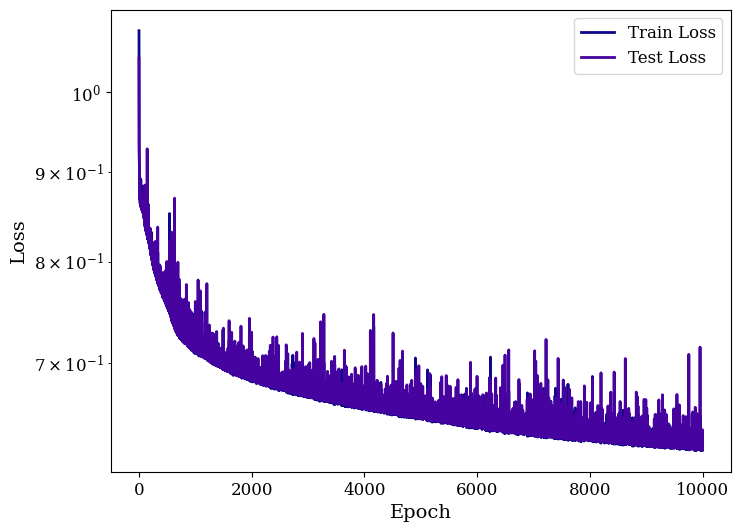

In [39]:

plt.figure()
set_plot_params()
plt.semilogy(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.semilogy(range(1, num_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


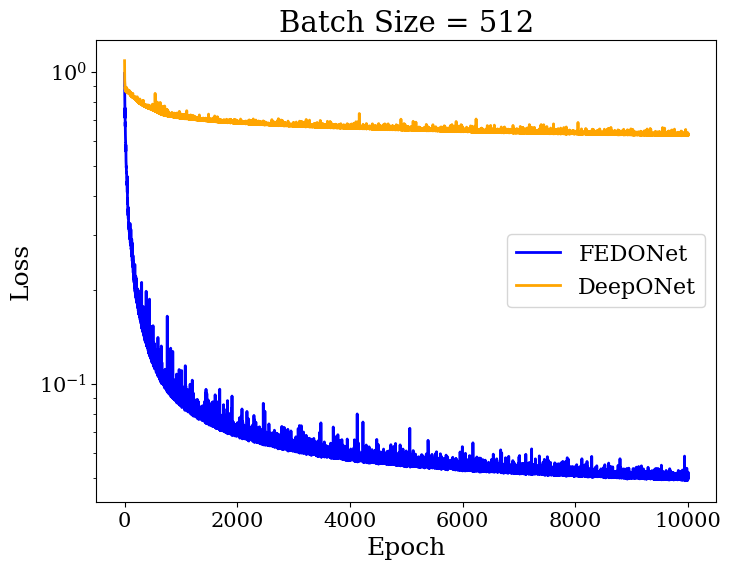

In [40]:

plt.figure()
set_plot_params() 
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
}) 
plt.semilogy(range(1, 10000+1), train_losses_fourier, color='blue', label='FEDONet')
plt.semilogy(range(1, num_epochs+1), train_losses, color='orange', label='DeepONet')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Batch Size = {batch_size}')
plt.show()

In [41]:
# Making Prediction
initial_condition, full_solution = next(iter(test_loader))
initial_condition = initial_condition.to(device)
full_solution = full_solution.to(device)

model.eval()
model_normal.eval()
with torch.no_grad():
    outputs = model(initial_condition, coords.to(device))
    outputs_normal = model_normal(initial_condition, coords.to(device))

initial_condition = initial_condition.cpu().numpy()
full_solution = full_solution.cpu().numpy()
coords = coords.cpu().numpy()
outputs = outputs.cpu().numpy()
outputs_normal = outputs_normal.cpu().numpy()

C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


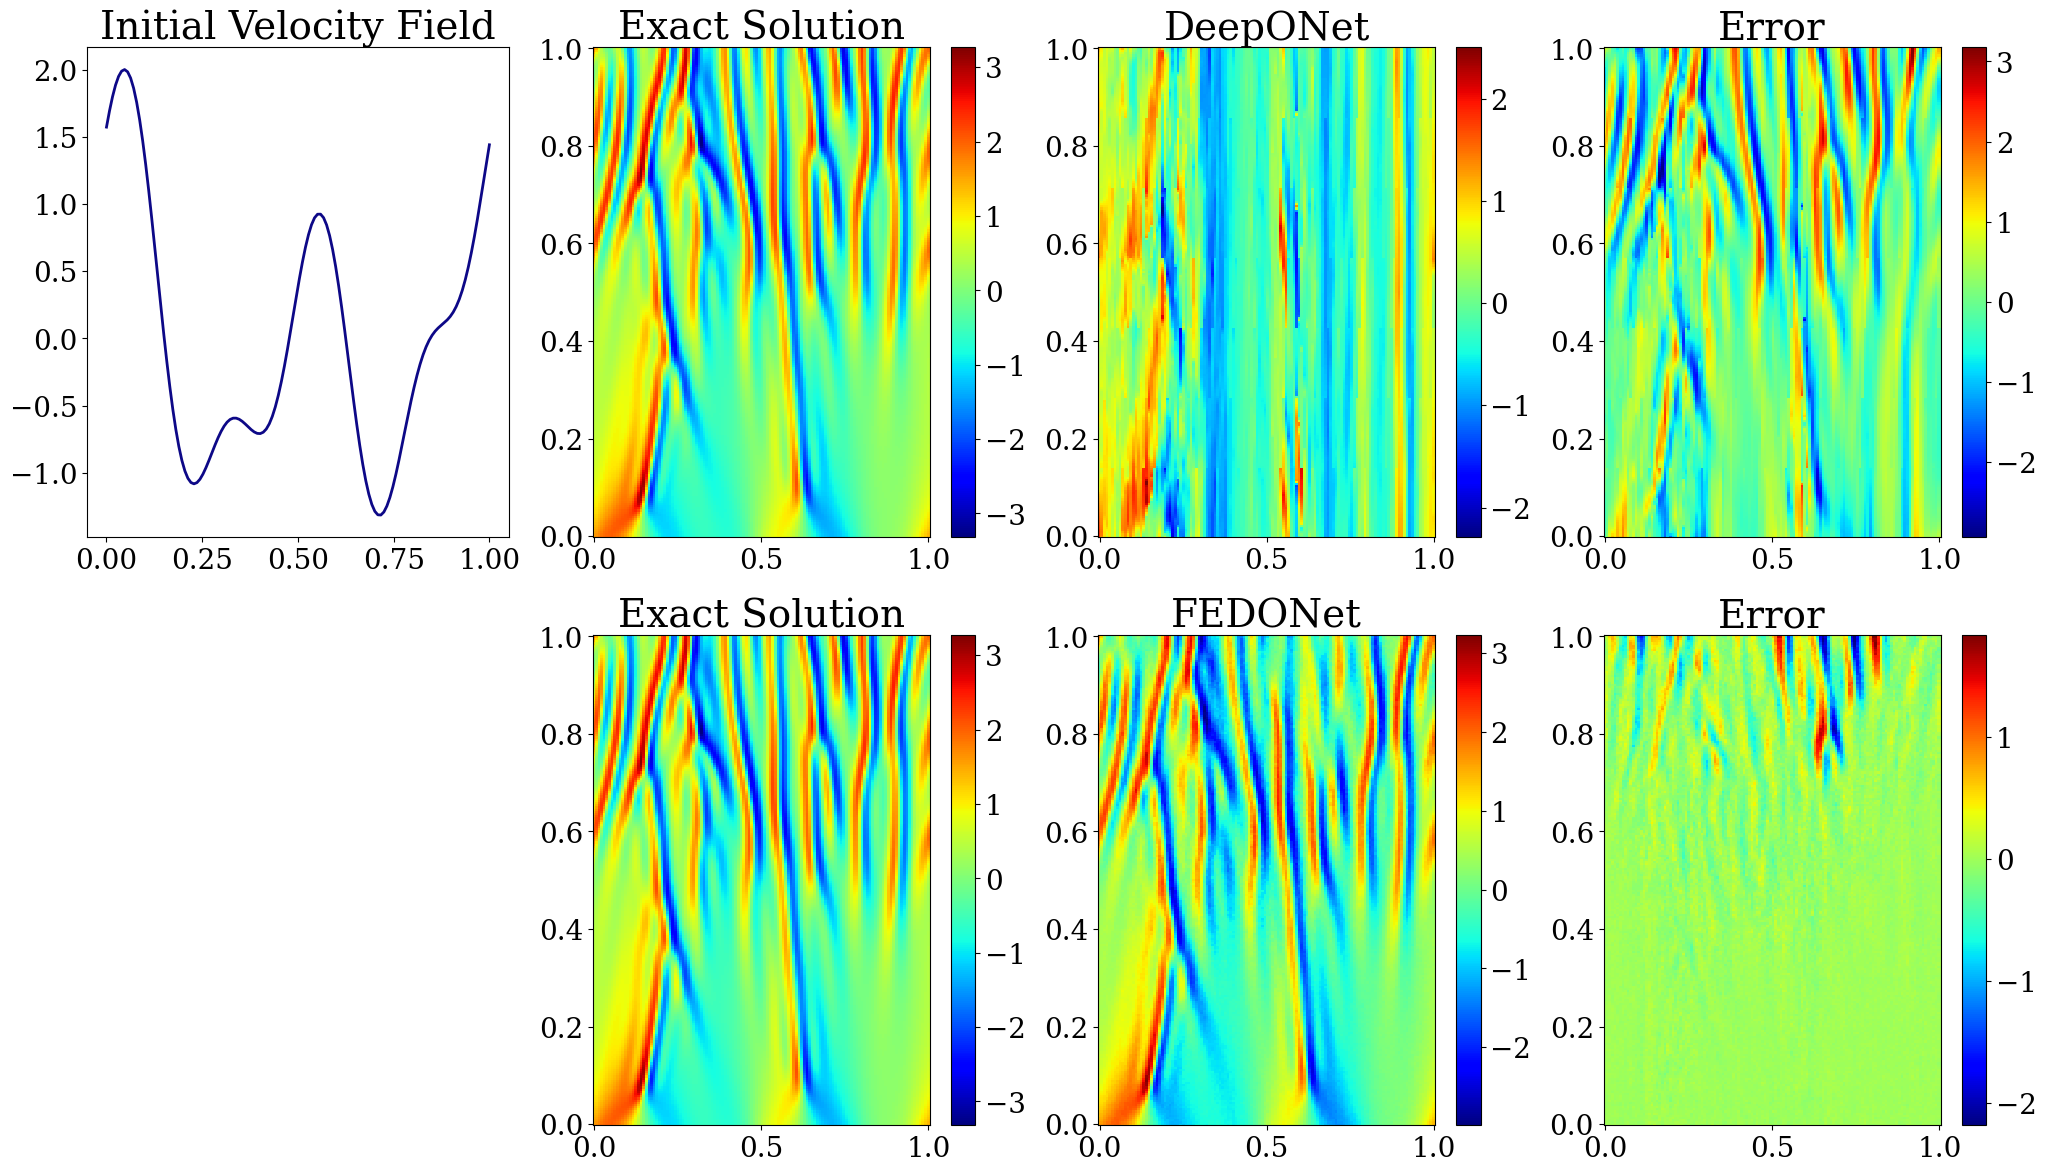

In [42]:
# Plotting
idx = np.random.randint(0, initial_condition.shape[0])
idx = 71
# idx = 327
set_plot_params()

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

fig = plt.figure(figsize=(25, 14))
x = np.linspace(0,1,128)
# Plot the initial condition
plt.subplot(2, 4, 1)
plt.plot(x, initial_condition[idx])
plt.title('Initial Velocity Field')

# Plot the exact/Numerical Solution
ax3 = fig.add_subplot(242)
c3 = ax3.pcolor( XX, TT, full_solution[idx].T, cmap='jet')
ax3.set_title('Exact Solution')
fig.colorbar(c3, ax=ax3)

# plot the solution given by DeepONet - Fourier Embedded
ax4 = fig.add_subplot(247)
c4 = ax4.pcolor( XX, TT, outputs[idx].T, cmap='jet')
ax4.set_title('FEDONet')
fig.colorbar(c4, ax=ax4)

# Plot the error DeepONet - Fourier Embedded
ax5 = fig.add_subplot(248)
c5 = ax5.pcolor( XX, TT,  full_solution[idx].T - outputs[idx].T, cmap='jet')
ax5.set_title('Error')
fig.colorbar(c5, ax=ax5)


# Plot the initial condition
# plt.subplot(1, 4, 1)
# plt.plot(initial_condition[idx])
# plt.title('Initial Velocity Field')

# Plot the exact/Numerical Solution
ax6 = fig.add_subplot(246)
c6 = ax6.pcolor( XX, TT, full_solution[idx].T, cmap='jet')
ax6.set_title('Exact Solution')
fig.colorbar(c6, ax=ax6)

# plot the solution given by DeepONet - Normal
ax7 = fig.add_subplot(243)
c7 = ax7.pcolor( XX, TT, outputs_normal[idx].T, cmap='jet')
ax7.set_title('DeepONet')
fig.colorbar(c7, ax=ax7)


# Plot the error DeepONet - Normal
ax8 = fig.add_subplot(244)
c8 = ax8.pcolor( XX, TT,  full_solution[idx].T - outputs_normal[idx].T, cmap='jet')
ax8.set_title('Error')
fig.colorbar(c8, ax=ax8)


plt.show()


In [43]:
# plt.figure(figsize=(14,6))

# plt.subplot(1,2,1)
# # Exact solution contours
# cs1 = plt.contour(full_solution[idx].T, levels=20, cmap='Blues', linewidths=2, linestyles='dashed')
# # Approximate solution contours DeepONet Normal
# cs2 = plt.contour(outputs_normal[idx].T, levels=20, cmap='Reds', linewidths=1)
# plt.title("Overlay Contour Plot: Exact (Blue) vs Vanilla DeepONet (Red)")
# plt.xlabel('x')
# plt.ylabel('t')
# plt.legend(["Exact", "Approximate"])

# plt.subplot(1,2,2)
# # Exact solution contours
# cs3 = plt.contour(full_solution[idx].T, levels=20, cmap='Blues', linewidths=2, linestyles='dashed')
# # Approximate solution contours DeepONet - Fourier Embedded 
# cs4 = plt.contour(outputs[idx].T, levels=20, cmap='Reds', linewidths=1)
# plt.title("Overlay Contour Plot: Exact (Blue) vs Fourier DeepONet (Red)")
# plt.xlabel('x')
# plt.ylabel('t')
# plt.legend(["Exact", "Approximate"])
# plt.show()

# def compute_energy_spectrum_1d(field):
   
#     N = len(field)
#     fft_field = np.fft.fft(field)
#     fft_mag_sq = np.abs(fft_field) ** 2
#     Ek = 0.5 * fft_mag_sq / N**2  # Normalize energy
#     k_vals = np.fft.fftfreq(N) * N  # integer-valued wave numbers

#     ## Here we just care about the non-negative frequencies
#     half_N = N // 2
#     return k_vals[:half_N], Ek[:half_N]

def compute_energy_spectrum_1d(u):
    """
    Computes the energy spectrum of a 1D velocity field.

    Parameters:
        u (numpy array): The velocity field.
        x (numpy array): The spatial grid points corresponding to u.

    Returns:
        k_sorted (numpy array): Sorted wavenumbers.
        E_k_sorted (numpy array): Corresponding energy spectrum values.
    """
    N = len(u)  # Number of points
    x = np.linspace(0,1,128)
    dx = x[1] - x[0]  # Grid spacing

    u_hat = np.fft.fft(u)  # Compute FFT
    k = np.fft.fftfreq(N, d=dx) * 2 * np.pi  # Compute wavenumbers
    E_k = (np.abs(u_hat)**2) / N  # Compute energy spectrum

    # Sort for visualization
    k_sorted = np.fft.fftshift(k)  
    E_k_sorted = np.fft.fftshift(E_k)

    return k_sorted[N//2+1:], E_k_sorted[N//2+1:]

def smooth_spectrum(Ek, window_len=5):
    """5-point moving average to reduce high-k noise."""
    return np.convolve(Ek, np.ones(window_len)/window_len, mode='same')


C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.
C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\3004647472.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\3004647472.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\3004647472.py:286: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


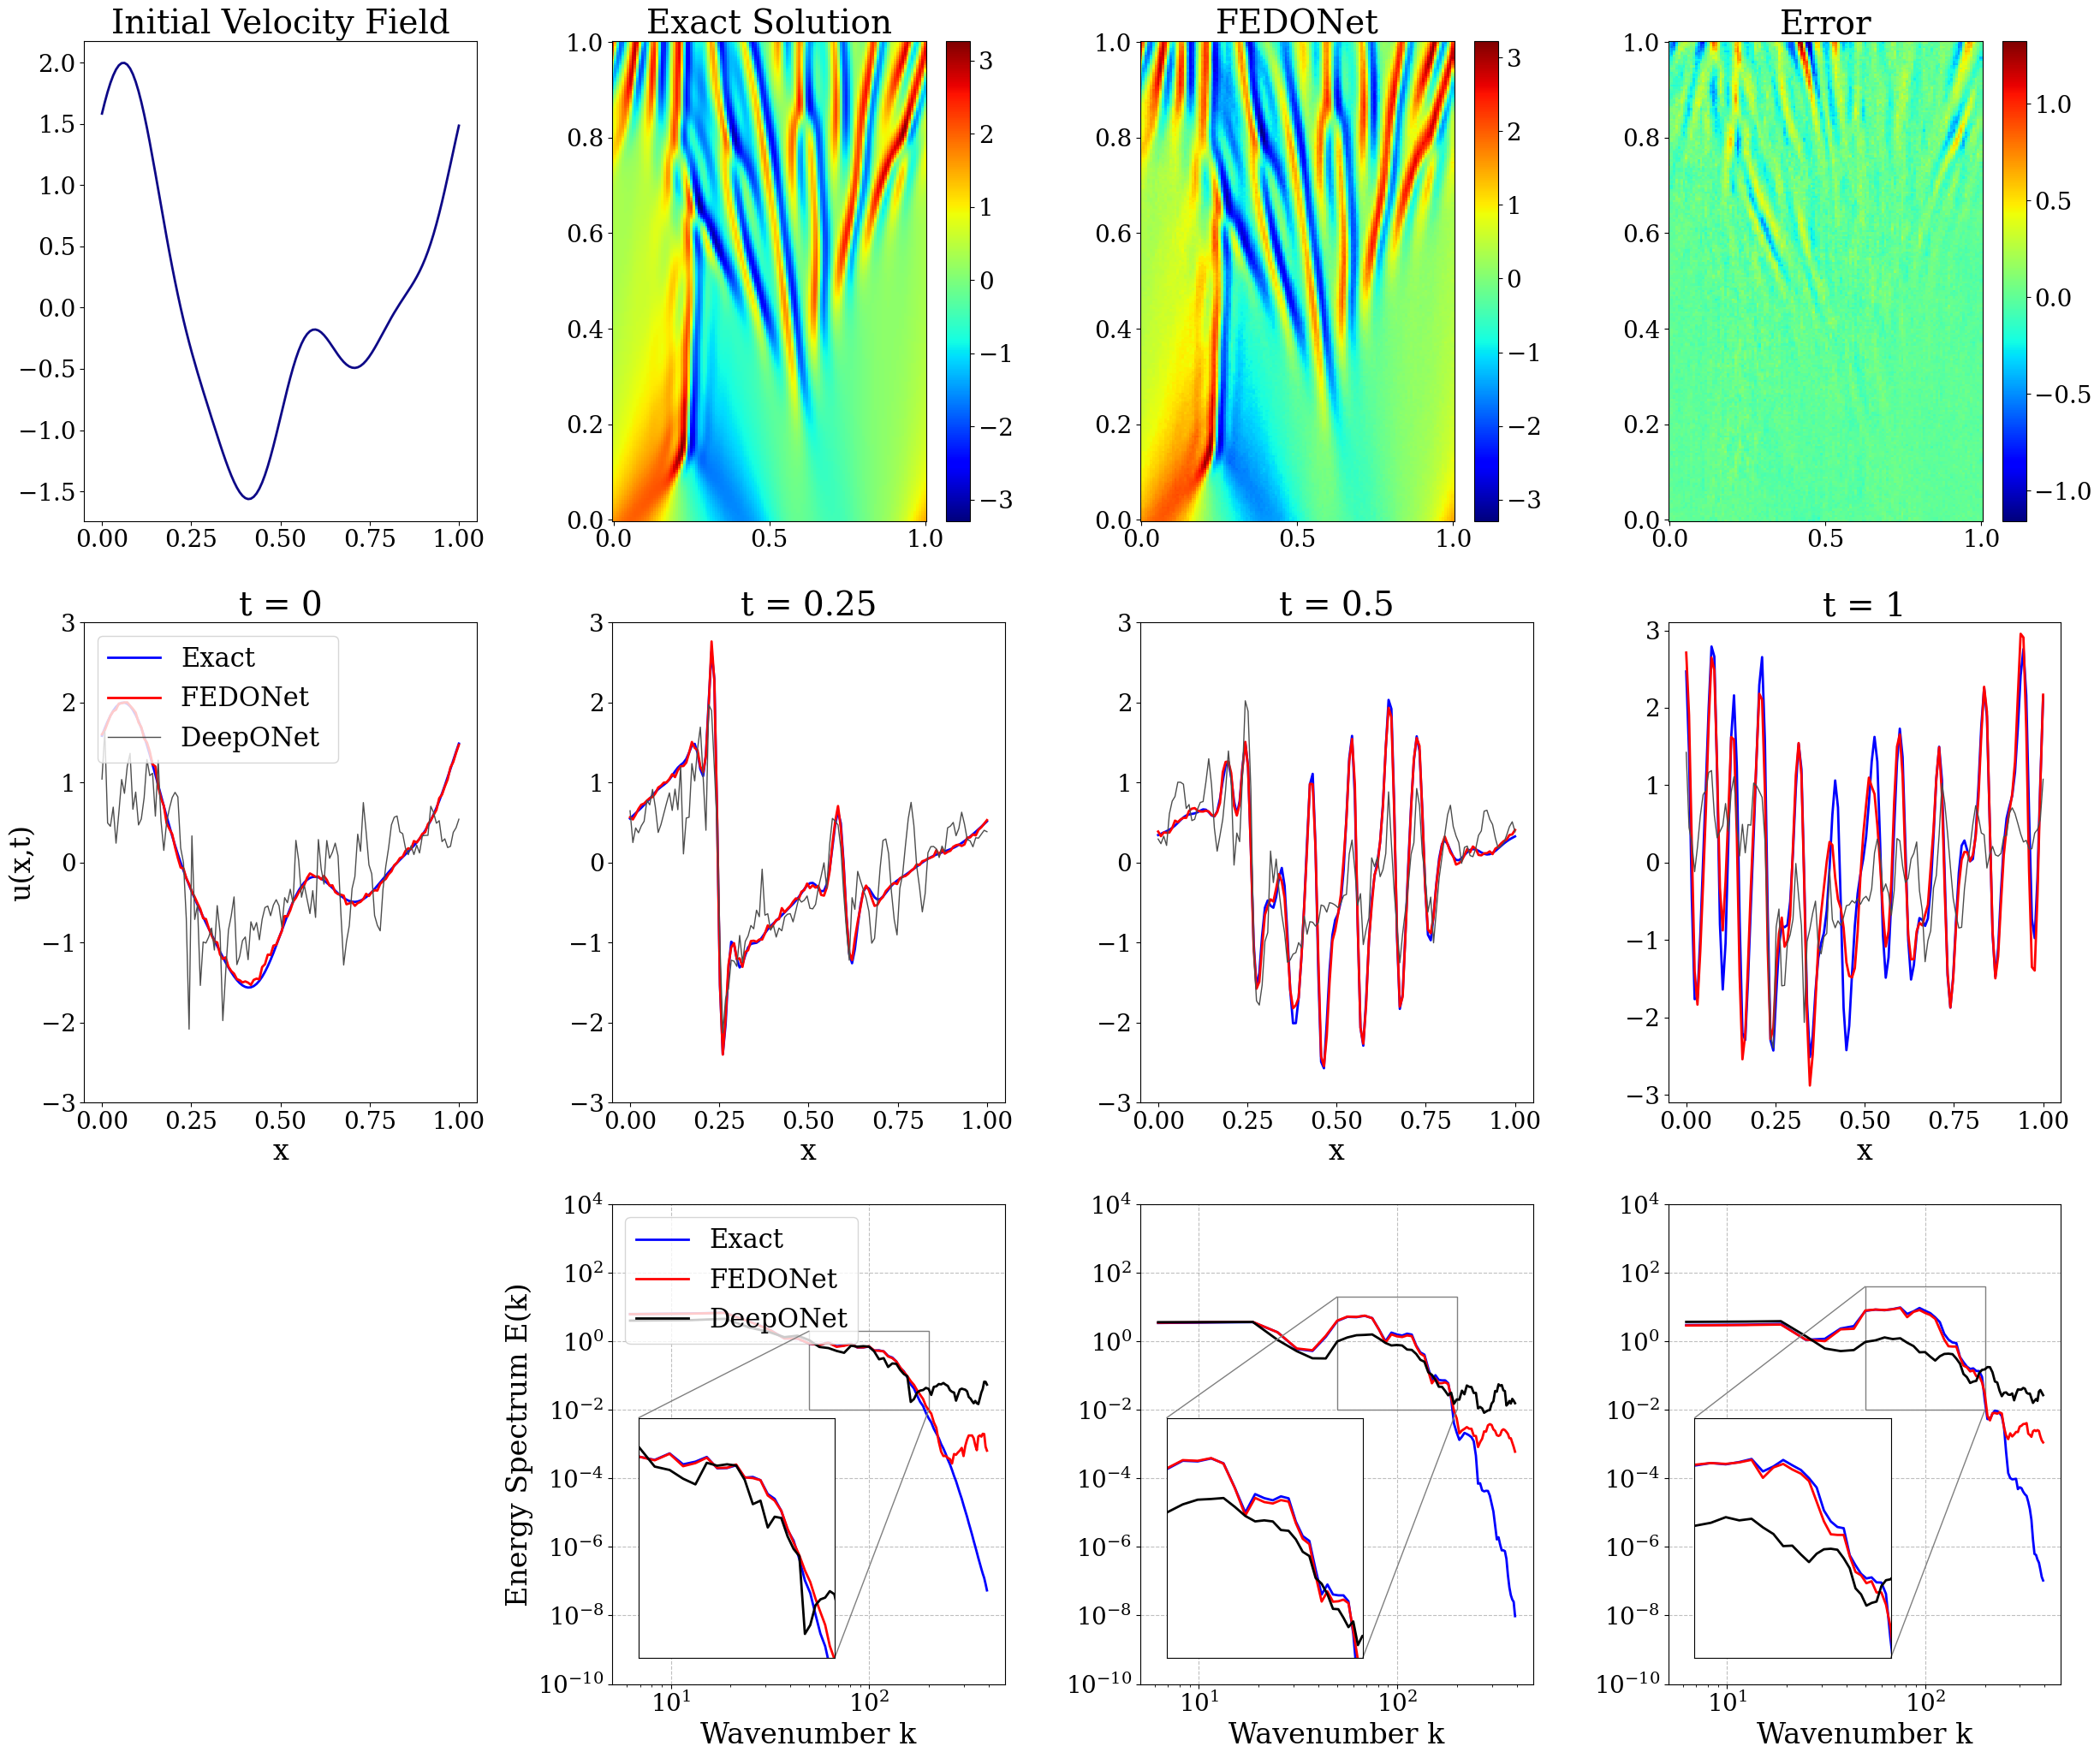

In [44]:
# Plotting
# idx = np.random.randint(0, initial_condition.shape[0])
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes
fig = plt.figure(figsize=(25, 21))
idx = 223 
set_plot_params()

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

x = np.linspace(0,1,128)

# Plot the initial condition
plt.subplot(3, 4, 1)
plt.plot(x,initial_condition[idx])
plt.title('Initial Velocity Field')

# Plot the exact/Numerical Solution
ax3 = fig.add_subplot(342)
c3 = ax3.pcolor( XX, TT, full_solution[idx].T, cmap='jet')
ax3.set_title('Exact Solution')
fig.colorbar(c3, ax=ax3)

# plot the solution given by DeepONet - Fourier Embedded
ax4 = fig.add_subplot(343)
c4 = ax4.pcolor( XX, TT, outputs[idx].T, cmap='jet')
ax4.set_title('FEDONet')
fig.colorbar(c4, ax=ax4)

# Plot the error DeepONet - Fourier Embedded
ax5 = fig.add_subplot(344)
c5 = ax5.pcolor( XX, TT,  full_solution[idx].T - outputs[idx].T, cmap='jet')
ax5.set_title('Error')
fig.colorbar(c5, ax=ax5)


# fig_2 = plt.figure(figsize=(25, 6))
# Plot the initial condition
plt.subplot(3, 4, 5)
plt.plot(x, full_solution[idx,:,0].squeeze(), linewidth=2, color='b', label='Exact')
plt.plot(x, outputs[idx,:,0].squeeze(), linewidth=2, color='red', label='FEDONet ')
plt.plot(x, outputs_normal[idx,:,0].squeeze(), linewidth=1, color='0.3', label='DeepONet ')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('t = 0')
plt.ylim([-3,3])
plt.legend(loc='upper left')

# Plot the exact/Numerical Solution
plt.subplot(3, 4, 6)
plt.plot(x, full_solution[idx,:,56].squeeze(), linewidth=2, color='b', label='Exact')
plt.plot(x, outputs[idx,:,56].squeeze(), linewidth=2, color='red', label='Fourier Embedded DeepONet ')
plt.plot(x, outputs_normal[idx,:,56].squeeze(), linewidth=1, color='0.3', label='Vanilla DeepONet ')
plt.ylim([-3,3])
plt.xlabel('x')
plt.title('t = 0.25')

# plot the solution given by DeepONet - Normal
plt.subplot(3, 4, 7)
plt.plot(x, full_solution[idx,:,112].squeeze(), linewidth=2, color='b', label='Exact')
plt.plot(x, outputs[idx,:,112].squeeze(), linewidth=2, color='red', label='Fourier Embedded DeepONet ')
plt.plot(x, outputs_normal[idx,:,112].squeeze(), linewidth=1, color='0.3', label='Vanilla DeepONet ')
plt.ylim([-3,3])
plt.xlabel('x')
plt.title('t = 0.5')

# Plot the error DeepONet - Normal
plt.subplot(3, 4, 8)
plt.plot(x, full_solution[idx,:,-1].squeeze(), linewidth=2, color='b', label='Exact')
plt.plot(x, outputs[idx,:,-1].squeeze(), linewidth=2, color='red', label='Fourier Embedded DeepONet ')
plt.plot(x, outputs_normal[idx,:,-1].squeeze(), linewidth=1, color='0.3', label='Vanilla DeepONet ')
plt.ylim([-3.1,3.1])
plt.xlabel('x')
plt.title('t = 1')

import seaborn as sns
k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,1])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,1])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,1])

# Create figure with two subplots

# Create figure and main plot
# plt.subplot(3, 4, 9)
# plt.loglog(k_vals, E_vals, 'b-', label='Exact')
# plt.loglog(k_vals_fourier, E_vals_fourier, 'r-', label='Fourier Embedded DeepONet')
# plt.loglog(k_vals_normal, E_vals_normal, 'k-', label='Vanilla DeepONet')
# plt.xlabel('Wavenumber k')
# plt.ylabel('Energy E(k)')
# plt.legend(loc='upper left')  # Legend at top-right
# # plt.ylim([1e-16,1e4])
# plt.grid(True)

k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,0])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,0])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,0])

# Create figure with two subplots



k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,56])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,56])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,56])

# Create figure with two subplots

# Create figure and main plot
ax = plt.subplot(3, 4, 10)

# Main plot
ax.loglog(k_vals, smooth_spectrum(E_vals), 'b-', label='Exact')
ax.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-', label='FEDONet')
ax.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-', label='DeepONet')

ax.set_xlabel('Wavenumber k')
ax.set_ylabel('Energy Spectrum E(k)')
ax.legend(loc='upper left')
ax.grid(True)
ax.set_ylim([1e-10,1e4])


# Inset (Zoomed-in region)
axins = inset_axes(ax, width="50%", height="50%", loc="lower left", borderpad=1)
axins.loglog(k_vals, smooth_spectrum(E_vals), 'b-')
axins.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-')
axins.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-')

# Set zoomed range
axins.set_xlim(50, 200)
axins.set_ylim(1e-2, 2)
axins.grid(True)

# Remove ticks from inset
axins.set_xticks([])
axins.set_yticks([])
axins.xaxis.set_tick_params(which='both', size=0, labelbottom=False)
axins.yaxis.set_tick_params(which='both', size=0, labelleft=False)

# Mark the zoomed-in area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()


k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,112])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,112])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,112])

# Create figure with two subplots

# Create figure and main plot
ax = plt.subplot(3, 4, 11)

# Main plot
ax.loglog(k_vals, smooth_spectrum(E_vals), 'b-', label='Exact')
ax.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-', label='Fourier Embedded DeepONet')
ax.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-', label='Vanilla DeepONet')

ax.set_xlabel('Wavenumber k')
# ax.set_ylabel('Energy E(k)')
# ax.legend(loc='upper left')
ax.grid(True)
ax.set_ylim([1e-10,1e4])


# Inset (Zoomed-in region)
axins = inset_axes(ax, width="50%", height="50%", loc="lower left", borderpad=1)
axins.loglog(k_vals, smooth_spectrum(E_vals), 'b-')
axins.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-')
axins.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-')

# Set zoomed range
axins.set_xlim(50, 200)
axins.set_ylim(1e-2, 20)
axins.grid(True)

# Remove ticks from inset
axins.set_xticks([])
axins.set_yticks([])
axins.xaxis.set_tick_params(which='both', size=0, labelbottom=False)
axins.yaxis.set_tick_params(which='both', size=0, labelleft=False)

# Mark the zoomed-in area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
# plt.subplot(3, 4, 9)
# # Flatten the arrays to ensure proper KDE behavior
# sns.kdeplot(full_solution[idx, :, 0].flatten(), fill=True, label="Exact", color="blue", alpha=1, linewidth=2, zorder=1)
# sns.kdeplot(outputs[idx, :, 0].flatten(), fill=True, label="Fourier Embedded DeepONet", color="red", alpha=0.4, linewidth=2, zorder=2)
# plt.xlabel("u(x,t=0)")
# plt.ylabel("Probability Density")
# # plt.title("PDF of Velocity Field")
# plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
# # plt.ylim([0,3.5])
# plt.grid()

k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,-1])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,-1])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,-1])

# Create figure with two subplots

# Create figure and main plot
# plt.subplot(3, 4, 12)
# plt.loglog(k_vals, E_vals, 'b-', label='Exact')
# plt.loglog(k_vals_fourier, E_vals_fourier, 'r-', label='Fourier Embedded DeepONet')
# plt.loglog(k_vals_normal, E_vals_normal, 'k-', label='Vanilla DeepONet')
# plt.xlabel('Wavenumber k')
# # plt.ylabel('Energy E(k)')
# plt.ylim([1e-16,1e4])
# plt.grid(True)
# # Inset (Zoomed-in region)
# axins = inset_axes(plt, width="35%", height="35%", loc="lower right", borderpad=1)
# axins.loglog(k_vals, E_vals, 'b-')
# axins.loglog(k_vals_fourier, E_vals_fourier, 'r-')
# axins.loglog(k_vals_normal, E_vals_normal, 'k-')  # Add normal DeepONet to inset if needed

# # Set zoomed range
# axins.set_xlim(80, 125)
# axins.set_ylim(1.8e-4, 3e-4)
# axins.grid(True)

# # Remove ticks from inset
# axins.set_xticks([])
# axins.set_yticks([])
# axins.xaxis.set_tick_params(which='both', size=0)
# axins.yaxis.set_tick_params(which='both', size=0)
# axins.xaxis.set_tick_params(which='both', size=0, labelbottom=False)
# axins.yaxis.set_tick_params(which='both', size=0, labelleft=False)

# # Mark the zoomed-in area
# mark_inset(plt, axins, loc1=2, loc2=1, fc="none", ec="0.5")

# plt.subplot(3, 4, 10)
# # Flatten the arrays to ensure proper KDE behavior
# sns.kdeplot(full_solution[idx, :, 56].flatten(), fill=True, label="Exact", color="blue", alpha=1, linewidth=2, zorder=1)
# sns.kdeplot(outputs[idx, :, 56].flatten(), fill=True, label="Vanilla DeepONet", color="red", alpha=0.4, linewidth=2, zorder=2)
# plt.xlabel("u(x,t=0.25)")
# # plt.ylabel("Probability Density")
# # plt.title("PDF of Velocity Field")
# # plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
# # plt.ylim([0,3.5])
# plt.grid()
ax = plt.subplot(3, 4, 12)

# Main plot
ax.loglog(k_vals, smooth_spectrum(E_vals), 'b-', label='Exact')
ax.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-', label='Fourier Embedded DeepONet')
ax.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-', label='Vanilla DeepONet')

ax.set_xlabel('Wavenumber k')
# ax.set_ylabel('Energy E(k)')
# ax.legend(loc='upper left')
ax.grid(True)
ax.set_ylim([1e-10,1e4])


# Inset (Zoomed-in region)
axins = inset_axes(ax, width="50%", height="50%", loc="lower left", borderpad=1)
axins.loglog(k_vals, smooth_spectrum(E_vals), 'b-')
axins.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-')
axins.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-')

# Set zoomed range
axins.set_xlim(50, 200)
axins.set_ylim(1e-2, 40)
axins.grid(True)

# Remove ticks from inset
axins.set_xticks([])
axins.set_yticks([])
axins.xaxis.set_tick_params(which='both', size=0, labelbottom=False)
axins.yaxis.set_tick_params(which='both', size=0, labelleft=False)

# Mark the zoomed-in area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()

plt.show()

# plt.subplot(3, 4, 11)
# # Flatten the arrays to ensure proper KDE behavior
# sns.kdeplot(full_solution[idx, :, 112].flatten(), fill=True, label="Exact", color="blue", alpha=1, linewidth=2, zorder=1)
# sns.kdeplot(outputs[idx, :, 112].flatten(), fill=True, label="Vanilla DeepONet", color="red", alpha=0.4, linewidth=2, zorder=2)
# plt.xlabel("u(x,t=0.5)")
# # plt.ylabel("Probability Density")
# # plt.title("PDF of Velocity Field")
# # plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
# # plt.ylim([0,3.5])
# plt.grid()

# plt.subplot(3, 4, 12)
# # Flatten the arrays to ensure proper KDE behavior
# sns.kdeplot(full_solution[idx, :, -1].flatten(), fill=True, label="Exact", color="blue", alpha=1, linewidth=2, zorder=1)
# sns.kdeplot(outputs[idx, :, -1].flatten(), fill=True, label="Vanilla DeepONet", color="red", alpha=0.4, linewidth=2, zorder=2)
# plt.xlabel("u(x,t=1)")
# # plt.ylabel("Probability Density")
# # plt.title("PDF of Velocity Field")
# # plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
# # plt.ylim([0,3.5])
# plt.grid()


C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.
C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\2612773382.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\2612773382.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\2612773382.py:286: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


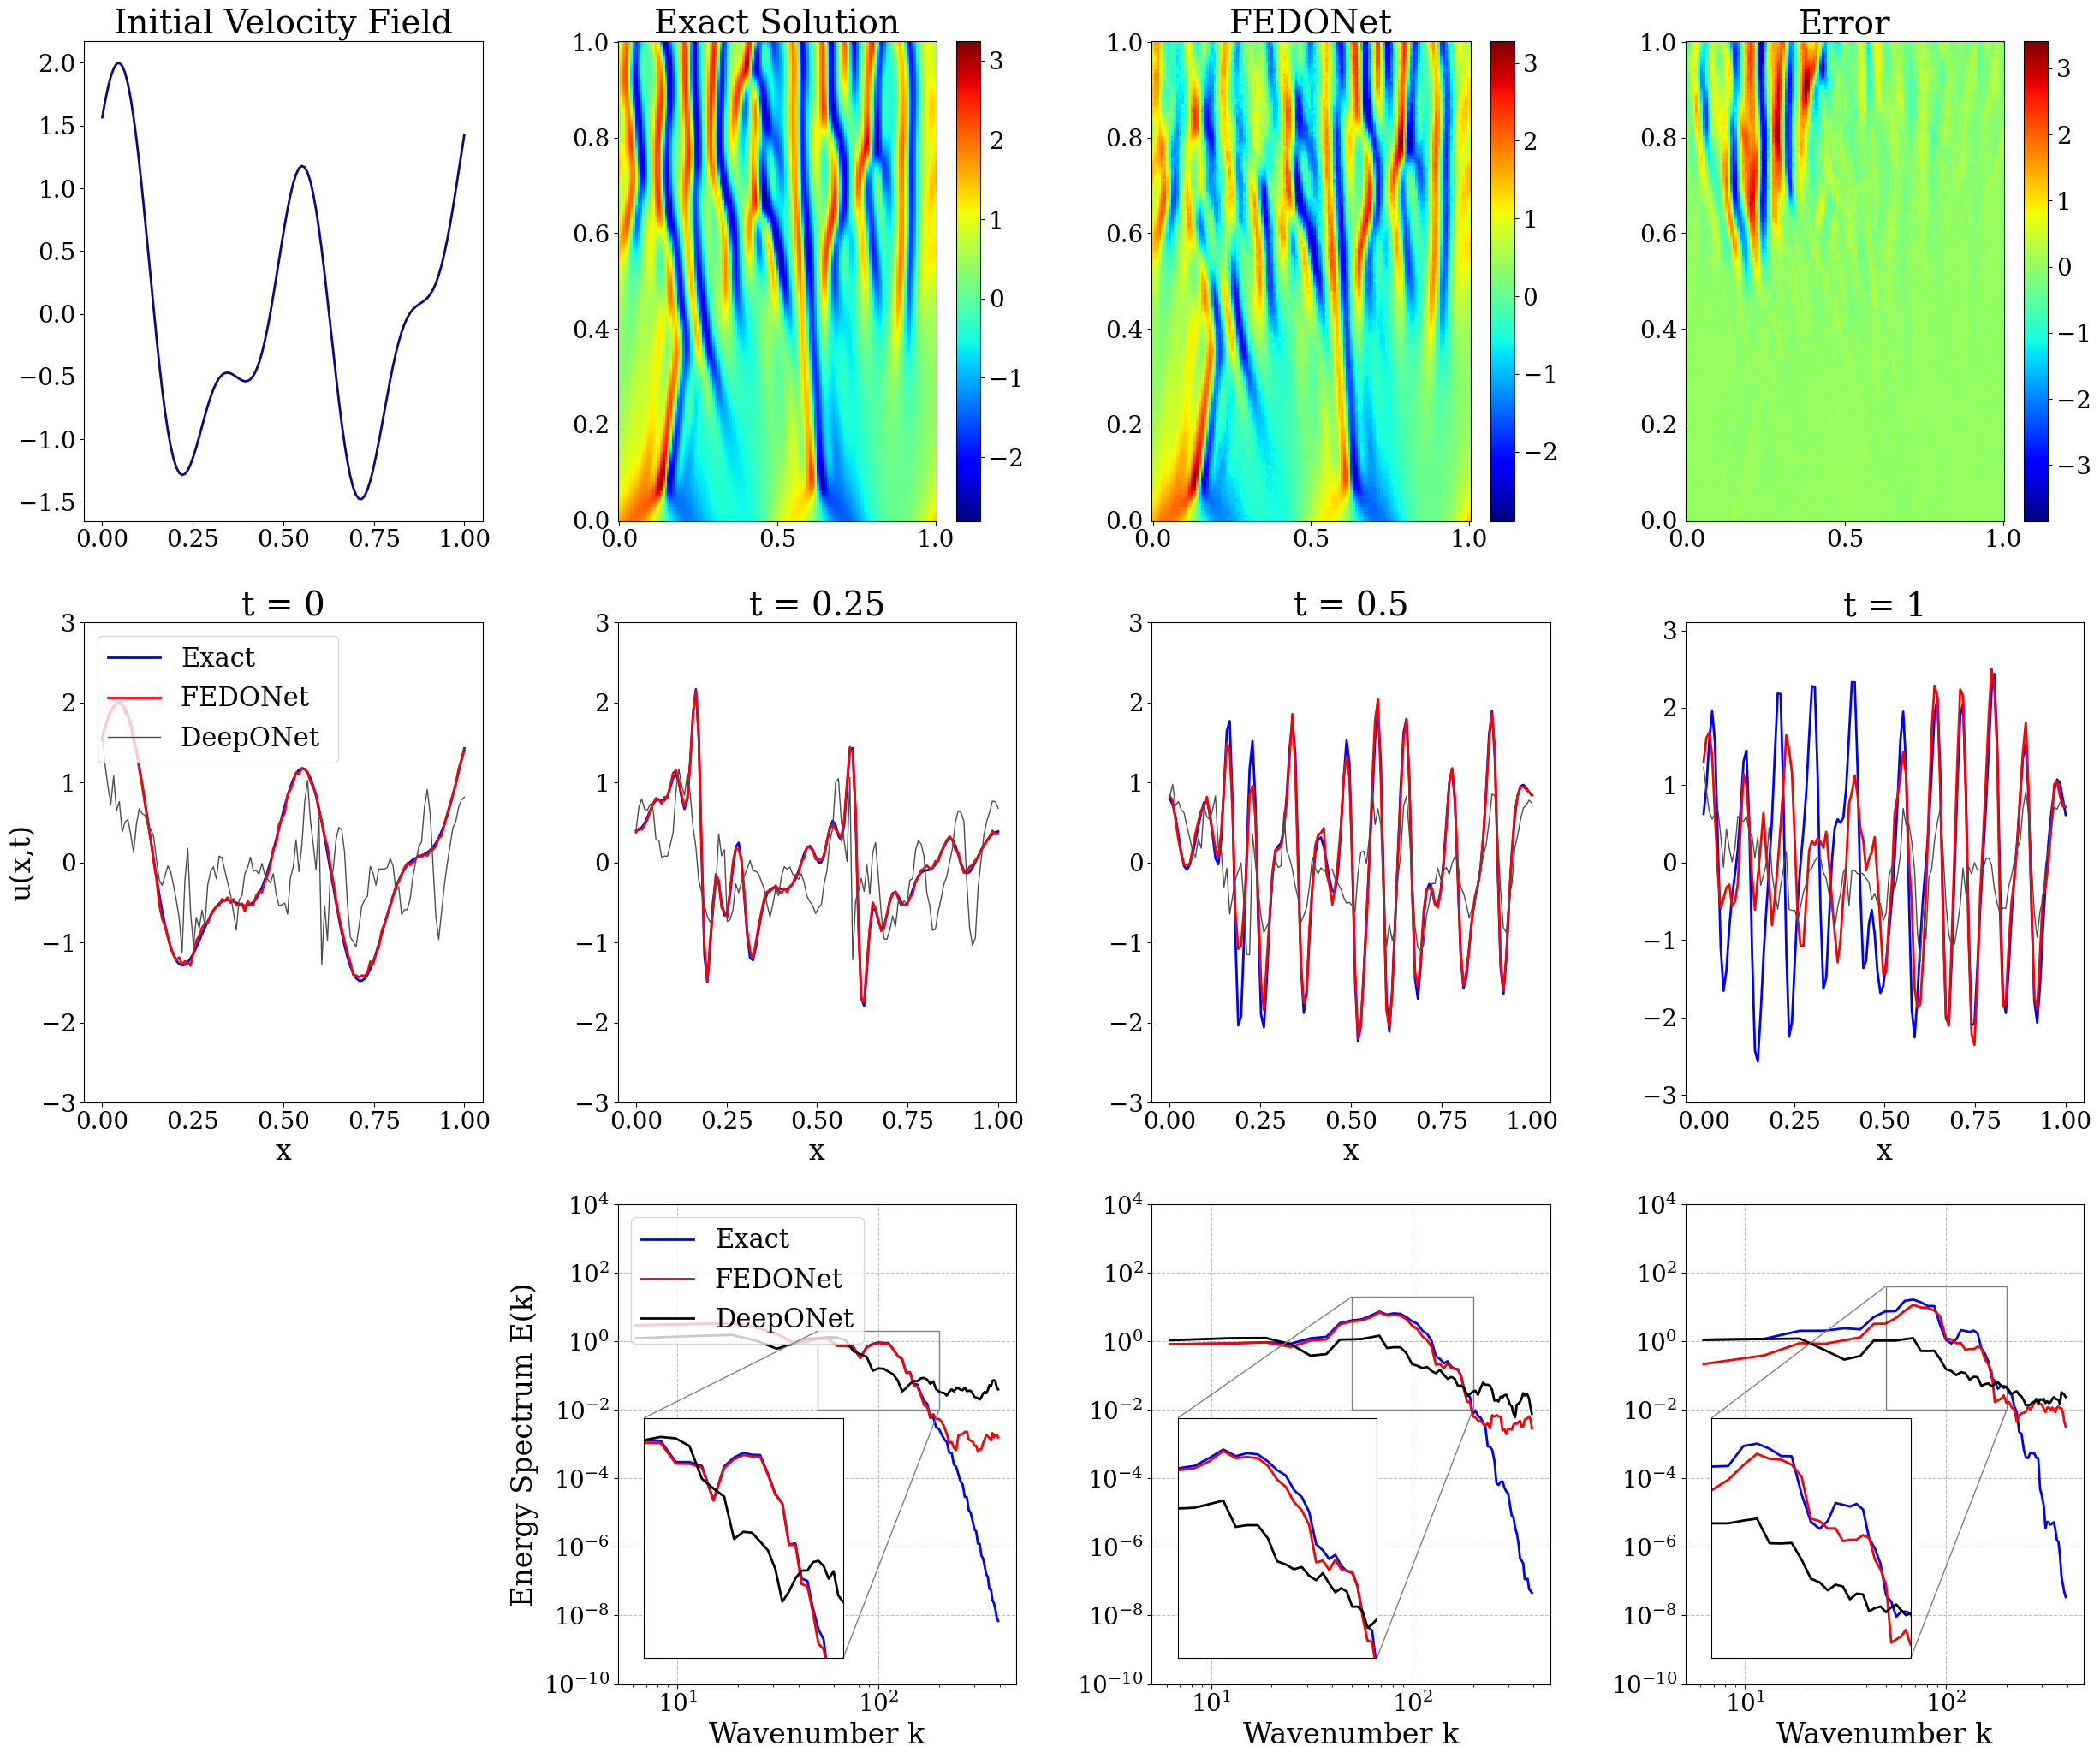

In [45]:
# Plotting
# idx = np.random.randint(0, initial_condition.shape[0])
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes
fig = plt.figure(figsize=(25, 21))
idx = 76 # 223-best 76-worst
set_plot_params()

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

x = np.linspace(0,1,128)

# Plot the initial condition
plt.subplot(3, 4, 1)
plt.plot(x,initial_condition[idx])
plt.title('Initial Velocity Field')

# Plot the exact/Numerical Solution
ax3 = fig.add_subplot(342)
c3 = ax3.pcolor( XX, TT, full_solution[idx].T, cmap='jet')
ax3.set_title('Exact Solution')
fig.colorbar(c3, ax=ax3)

# plot the solution given by DeepONet - Fourier Embedded
ax4 = fig.add_subplot(343)
c4 = ax4.pcolor( XX, TT, outputs[idx].T, cmap='jet')
ax4.set_title('FEDONet')
fig.colorbar(c4, ax=ax4)

# Plot the error DeepONet - Fourier Embedded
ax5 = fig.add_subplot(344)
c5 = ax5.pcolor( XX, TT,  full_solution[idx].T - outputs[idx].T, cmap='jet')
ax5.set_title('Error')
fig.colorbar(c5, ax=ax5)


# fig_2 = plt.figure(figsize=(25, 6))
# Plot the initial condition
plt.subplot(3, 4, 5)
plt.plot(x, full_solution[idx,:,0].squeeze(), linewidth=2, color='b', label='Exact')
plt.plot(x, outputs[idx,:,0].squeeze(), linewidth=2, color='red', label='FEDONet ')
plt.plot(x, outputs_normal[idx,:,0].squeeze(), linewidth=1, color='0.3', label='DeepONet ')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('t = 0')
plt.ylim([-3,3])
plt.legend(loc='upper left')

# Plot the exact/Numerical Solution
plt.subplot(3, 4, 6)
plt.plot(x, full_solution[idx,:,56].squeeze(), linewidth=2, color='b', label='Exact')
plt.plot(x, outputs[idx,:,56].squeeze(), linewidth=2, color='red', label='Fourier Embedded DeepONet ')
plt.plot(x, outputs_normal[idx,:,56].squeeze(), linewidth=1, color='0.3', label='Vanilla DeepONet ')
plt.ylim([-3,3])
plt.xlabel('x')
plt.title('t = 0.25')

# plot the solution given by DeepONet - Normal
plt.subplot(3, 4, 7)
plt.plot(x, full_solution[idx,:,112].squeeze(), linewidth=2, color='b', label='Exact')
plt.plot(x, outputs[idx,:,112].squeeze(), linewidth=2, color='red', label='Fourier Embedded DeepONet ')
plt.plot(x, outputs_normal[idx,:,112].squeeze(), linewidth=1, color='0.3', label='Vanilla DeepONet ')
plt.ylim([-3,3])
plt.xlabel('x')
plt.title('t = 0.5')

# Plot the error DeepONet - Normal
plt.subplot(3, 4, 8)
plt.plot(x, full_solution[idx,:,-1].squeeze(), linewidth=2, color='b', label='Exact')
plt.plot(x, outputs[idx,:,-1].squeeze(), linewidth=2, color='red', label='Fourier Embedded DeepONet ')
plt.plot(x, outputs_normal[idx,:,-1].squeeze(), linewidth=1, color='0.3', label='Vanilla DeepONet ')
plt.ylim([-3.1,3.1])
plt.xlabel('x')
plt.title('t = 1')

import seaborn as sns
k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,1])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,1])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,1])

# Create figure with two subplots

# Create figure and main plot
# plt.subplot(3, 4, 9)
# plt.loglog(k_vals, E_vals, 'b-', label='Exact')
# plt.loglog(k_vals_fourier, E_vals_fourier, 'r-', label='Fourier Embedded DeepONet')
# plt.loglog(k_vals_normal, E_vals_normal, 'k-', label='Vanilla DeepONet')
# plt.xlabel('Wavenumber k')
# plt.ylabel('Energy E(k)')
# plt.legend(loc='upper left')  # Legend at top-right
# # plt.ylim([1e-16,1e4])
# plt.grid(True)

k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,0])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,0])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,0])

# Create figure with two subplots



k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,56])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,56])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,56])

# Create figure with two subplots

# Create figure and main plot
ax = plt.subplot(3, 4, 10)

# Main plot
ax.loglog(k_vals, smooth_spectrum(E_vals), 'b-', label='Exact')
ax.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-', label='FEDONet')
ax.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-', label='DeepONet')

ax.set_xlabel('Wavenumber k')
ax.set_ylabel('Energy Spectrum E(k)')
ax.legend(loc='upper left')
ax.grid(True)
ax.set_ylim([1e-10,1e4])


# Inset (Zoomed-in region)
axins = inset_axes(ax, width="50%", height="50%", loc="lower left", borderpad=1)
axins.loglog(k_vals, smooth_spectrum(E_vals), 'b-')
axins.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-')
axins.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-')

# Set zoomed range
axins.set_xlim(50, 200)
axins.set_ylim(1e-2, 2)
axins.grid(True)

# Remove ticks from inset
axins.set_xticks([])
axins.set_yticks([])
axins.xaxis.set_tick_params(which='both', size=0, labelbottom=False)
axins.yaxis.set_tick_params(which='both', size=0, labelleft=False)

# Mark the zoomed-in area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()


k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,112])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,112])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,112])

# Create figure with two subplots

# Create figure and main plot
ax = plt.subplot(3, 4, 11)

# Main plot
ax.loglog(k_vals, smooth_spectrum(E_vals), 'b-', label='Exact')
ax.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-', label='Fourier Embedded DeepONet')
ax.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-', label='Vanilla DeepONet')

ax.set_xlabel('Wavenumber k')
# ax.set_ylabel('Energy E(k)')
# ax.legend(loc='upper left')
ax.grid(True)
ax.set_ylim([1e-10,1e4])


# Inset (Zoomed-in region)
axins = inset_axes(ax, width="50%", height="50%", loc="lower left", borderpad=1)
axins.loglog(k_vals, smooth_spectrum(E_vals), 'b-')
axins.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-')
axins.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-')

# Set zoomed range
axins.set_xlim(50, 200)
axins.set_ylim(1e-2, 20)
axins.grid(True)

# Remove ticks from inset
axins.set_xticks([])
axins.set_yticks([])
axins.xaxis.set_tick_params(which='both', size=0, labelbottom=False)
axins.yaxis.set_tick_params(which='both', size=0, labelleft=False)

# Mark the zoomed-in area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
# plt.subplot(3, 4, 9)
# # Flatten the arrays to ensure proper KDE behavior
# sns.kdeplot(full_solution[idx, :, 0].flatten(), fill=True, label="Exact", color="blue", alpha=1, linewidth=2, zorder=1)
# sns.kdeplot(outputs[idx, :, 0].flatten(), fill=True, label="Fourier Embedded DeepONet", color="red", alpha=0.4, linewidth=2, zorder=2)
# plt.xlabel("u(x,t=0)")
# plt.ylabel("Probability Density")
# # plt.title("PDF of Velocity Field")
# plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
# # plt.ylim([0,3.5])
# plt.grid()

k_vals, E_vals = compute_energy_spectrum_1d(full_solution[idx,:,-1])
k_vals_normal, E_vals_normal = compute_energy_spectrum_1d(outputs_normal[idx,:,-1])
k_vals_fourier, E_vals_fourier = compute_energy_spectrum_1d(outputs[idx,:,-1])

# Create figure with two subplots

# Create figure and main plot
# plt.subplot(3, 4, 12)
# plt.loglog(k_vals, E_vals, 'b-', label='Exact')
# plt.loglog(k_vals_fourier, E_vals_fourier, 'r-', label='Fourier Embedded DeepONet')
# plt.loglog(k_vals_normal, E_vals_normal, 'k-', label='Vanilla DeepONet')
# plt.xlabel('Wavenumber k')
# # plt.ylabel('Energy E(k)')
# plt.ylim([1e-16,1e4])
# plt.grid(True)
# # Inset (Zoomed-in region)
# axins = inset_axes(plt, width="35%", height="35%", loc="lower right", borderpad=1)
# axins.loglog(k_vals, E_vals, 'b-')
# axins.loglog(k_vals_fourier, E_vals_fourier, 'r-')
# axins.loglog(k_vals_normal, E_vals_normal, 'k-')  # Add normal DeepONet to inset if needed

# # Set zoomed range
# axins.set_xlim(80, 125)
# axins.set_ylim(1.8e-4, 3e-4)
# axins.grid(True)

# # Remove ticks from inset
# axins.set_xticks([])
# axins.set_yticks([])
# axins.xaxis.set_tick_params(which='both', size=0)
# axins.yaxis.set_tick_params(which='both', size=0)
# axins.xaxis.set_tick_params(which='both', size=0, labelbottom=False)
# axins.yaxis.set_tick_params(which='both', size=0, labelleft=False)

# # Mark the zoomed-in area
# mark_inset(plt, axins, loc1=2, loc2=1, fc="none", ec="0.5")

# plt.subplot(3, 4, 10)
# # Flatten the arrays to ensure proper KDE behavior
# sns.kdeplot(full_solution[idx, :, 56].flatten(), fill=True, label="Exact", color="blue", alpha=1, linewidth=2, zorder=1)
# sns.kdeplot(outputs[idx, :, 56].flatten(), fill=True, label="Vanilla DeepONet", color="red", alpha=0.4, linewidth=2, zorder=2)
# plt.xlabel("u(x,t=0.25)")
# # plt.ylabel("Probability Density")
# # plt.title("PDF of Velocity Field")
# # plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
# # plt.ylim([0,3.5])
# plt.grid()
ax = plt.subplot(3, 4, 12)

# Main plot
ax.loglog(k_vals, smooth_spectrum(E_vals), 'b-', label='Exact')
ax.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-', label='Fourier Embedded DeepONet')
ax.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-', label='Vanilla DeepONet')

ax.set_xlabel('Wavenumber k')
# ax.set_ylabel('Energy E(k)')
# ax.legend(loc='upper left')
ax.grid(True)
ax.set_ylim([1e-10,1e4])


# Inset (Zoomed-in region)
axins = inset_axes(ax, width="50%", height="50%", loc="lower left", borderpad=1)
axins.loglog(k_vals, smooth_spectrum(E_vals), 'b-')
axins.loglog(k_vals_fourier, smooth_spectrum(E_vals_fourier), 'r-')
axins.loglog(k_vals_normal, smooth_spectrum(E_vals_normal), 'k-')

# Set zoomed range
axins.set_xlim(50, 200)
axins.set_ylim(1e-2, 40)
axins.grid(True)

# Remove ticks from inset
axins.set_xticks([])
axins.set_yticks([])
axins.xaxis.set_tick_params(which='both', size=0, labelbottom=False)
axins.yaxis.set_tick_params(which='both', size=0, labelleft=False)

# Mark the zoomed-in area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()

plt.show()

# plt.subplot(3, 4, 11)
# # Flatten the arrays to ensure proper KDE behavior
# sns.kdeplot(full_solution[idx, :, 112].flatten(), fill=True, label="Exact", color="blue", alpha=1, linewidth=2, zorder=1)
# sns.kdeplot(outputs[idx, :, 112].flatten(), fill=True, label="Vanilla DeepONet", color="red", alpha=0.4, linewidth=2, zorder=2)
# plt.xlabel("u(x,t=0.5)")
# # plt.ylabel("Probability Density")
# # plt.title("PDF of Velocity Field")
# # plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
# # plt.ylim([0,3.5])
# plt.grid()

# plt.subplot(3, 4, 12)
# # Flatten the arrays to ensure proper KDE behavior
# sns.kdeplot(full_solution[idx, :, -1].flatten(), fill=True, label="Exact", color="blue", alpha=1, linewidth=2, zorder=1)
# sns.kdeplot(outputs[idx, :, -1].flatten(), fill=True, label="Vanilla DeepONet", color="red", alpha=0.4, linewidth=2, zorder=2)
# plt.xlabel("u(x,t=1)")
# # plt.ylabel("Probability Density")
# # plt.title("PDF of Velocity Field")
# # plt.legend(loc="upper left", bbox_to_anchor=(0, 1))
# # plt.ylim([0,3.5])
# plt.grid()


In [46]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

def compute_energy_spectrum(u, x):
    """
    Computes the energy spectrum of a 1D velocity field.

    Parameters:
        u (numpy array): The velocity field.
        x (numpy array): The spatial grid points corresponding to u.

    Returns:
        k_sorted (numpy array): Sorted wavenumbers.
        E_k_sorted (numpy array): Corresponding energy spectrum values.
    """
    N = len(u)  # Number of points
    dx = x[1] - x[0]  # Grid spacing

    u_hat = np.fft.fft(u)  # Compute FFT
    k = np.fft.fftfreq(N, d=dx) * 2 * np.pi  # Compute wavenumbers
    E_k = (np.abs(u_hat)**2) / N  # Compute energy spectrum

    # Sort for visualization
    k_sorted = np.fft.fftshift(k)  
    E_k_sorted = np.fft.fftshift(E_k)

    return k_sorted[N//2+1:], E_k_sorted[N//2+1:]


def compute_pdf(u, bins=50):
    """
    Computes the probability density function (PDF) of a 1D velocity field.

    Parameters:
        u (numpy array): The velocity field.
        bins (int): Number of bins for histogram computation.

    Returns:
        pdf_values (numpy array): Normalized probability density values.
        bin_centers (numpy array): Bin center locations.
    """
    hist, bin_edges = np.histogram(u, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers

    return bin_centers, hist

In [47]:
idx = 223
# Define table data
data_for_table = [
              ["MAE", compute_mae(full_solution[idx], outputs_normal[idx]), compute_mae(full_solution[idx], outputs[idx])], 
              ["Fourier MSE", compute_fourier_mse(full_solution[idx], outputs_normal[idx]), compute_fourier_mse(full_solution[idx], outputs[idx])],
              ["MSE", compute_mse(full_solution[idx], outputs_normal[idx]), compute_mse(full_solution[idx], outputs[idx])],
              ["SSIM", compute_ssim(full_solution[idx], outputs_normal[idx]), compute_ssim(full_solution[idx], outputs[idx])],
              ["PSNR", compute_psnr(full_solution[idx], outputs_normal[idx]), compute_psnr(full_solution[idx], outputs[idx])],
              ["Relative L2 Error (%)", compute_error_stats(full_solution[idx], outputs_normal[idx])*100, compute_error_stats(full_solution[idx], outputs[idx])*100]
              
]

# Define column headers
headers = ["Error - metrics", "Vanilla ( Original ) DeepONet", "Fourier Embedded DeepONet"]  # First column is for row names

# Print the formatted table
print(tabulate(data_for_table, headers=headers, tablefmt="grid", numalign="center", stralign="center"))


+-----------------------+---------------------------------+-----------------------------+
|    Error - metrics    |  Vanilla ( Original ) DeepONet  |  Fourier Embedded DeepONet  |
+=======================+=================================+=============================+
|          MAE          |            0.545433             |          0.0674382          |
+-----------------------+---------------------------------+-----------------------------+
|      Fourier MSE      |             15648.5             |           379.485           |
+-----------------------+---------------------------------+-----------------------------+
|          MSE          |            0.545776             |          0.0132354          |
+-----------------------+---------------------------------+-----------------------------+
|         SSIM          |            0.258534             |          0.969558           |
+-----------------------+---------------------------------+-----------------------------+
|         

C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


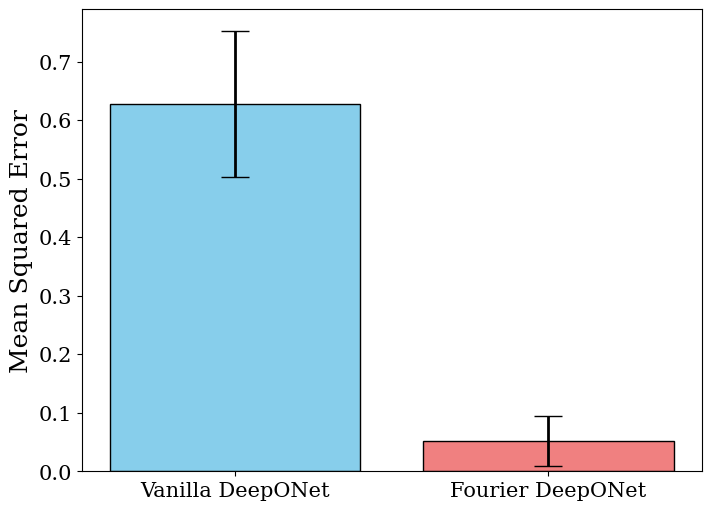

C:\Users\asojitra\AppData\Local\Temp\ipykernel_25144\1417028665.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma') # Can be changed to "jet", "viridis", etc.


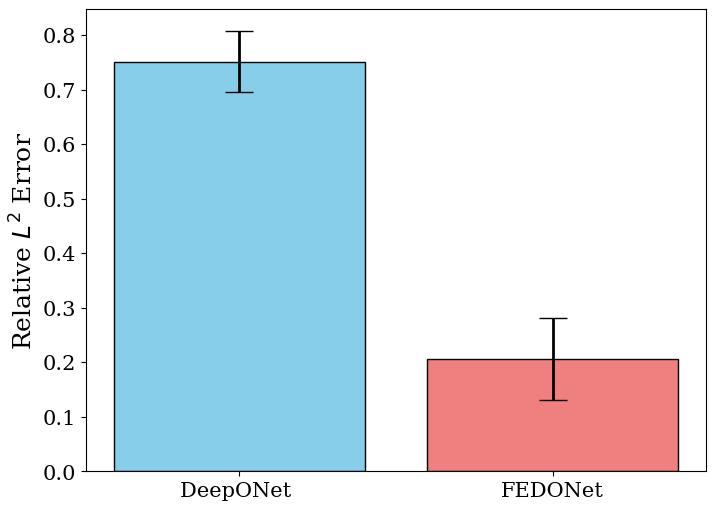

In [48]:
mse_normal_deeponet_array = np.zeros(initial_condition.shape[0])  
mse_fourier_deeponet_array = np.zeros(initial_condition.shape[0])
relative_l2_normal_deeponet_array = np.zeros(initial_condition.shape[0])
relative_l2_fourier_deeponet_array = np.zeros(initial_condition.shape[0])

for k in range(initial_condition.shape[0]):
    mse_normal_deeponet_array[k] = compute_mse(full_solution[k], outputs_normal[k])
    mse_fourier_deeponet_array[k] = compute_mse(full_solution[k], outputs[k])
    relative_l2_normal_deeponet_array[k] = compute_error_stats(full_solution[k], outputs_normal[k])
    relative_l2_fourier_deeponet_array[k] = compute_error_stats(full_solution[k], outputs[k])
    
    
# MSE plot
means = [np.mean(mse_normal_deeponet_array), np.mean(mse_fourier_deeponet_array)]
stds = [np.std(mse_normal_deeponet_array), np.std(mse_fourier_deeponet_array)]
x_labels = ["Vanilla DeepONet", "Fourier DeepONet"]
x_positions = np.arange(len(x_labels))  
set_plot_params()
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})
plt.figure(figsize=(8, 6))
plt.bar(x_positions, means, yerr=stds, capsize=10, color=["skyblue", "lightcoral"], edgecolor="black")
plt.xticks(x_positions, x_labels)  
plt.ylabel("Mean Squared Error")
plt.show()

# Relative L2 Plot
means = [np.mean(relative_l2_normal_deeponet_array), np.mean(relative_l2_fourier_deeponet_array)]
stds = [np.std(relative_l2_normal_deeponet_array), np.std(relative_l2_fourier_deeponet_array)]
x_labels = ["DeepONet ", "FEDONet"]
x_positions = np.arange(len(x_labels))  
set_plot_params()
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})
plt.figure(figsize=(8, 6))
plt.bar(x_positions, means, yerr=stds, capsize=10, color=["skyblue", "lightcoral"], edgecolor="black")
plt.xticks(x_positions, x_labels) 
plt.ylabel("Relative $L^2$ Error")
plt.show()

In [49]:
print(means[0])
print(means[1])

0.7511383257806301
0.20620974911435042


In [50]:
max_index = np.argmax(relative_l2_fourier_deeponet_array)
min_index = np.argmin(relative_l2_fourier_deeponet_array)

print("Index of max value:", max_index)
print("Index of min value:", min_index)

median_value = np.median(relative_l2_fourier_deeponet_array)
print("Median value:", median_value)

arr = relative_l2_fourier_deeponet_array

# Find the median value
median_value = np.median(arr)

# Find the index of the element closest to the median
median_index = np.abs(arr - median_value).argmin()

print("Median value:", median_value)
print("Index closest to median:", median_index)

Index of max value: 76
Index of min value: 223
Median value: 0.18399353325366974
Median value: 0.18399353325366974
Index closest to median: 327


Noise = 0.00 | FEDONet = 2.029417e-01 | DeepONet = 7.494971e-01
Noise = 0.01 | FEDONet = 2.051992e-01 | DeepONet = 7.496700e-01
Noise = 0.02 | FEDONet = 2.112755e-01 | DeepONet = 7.501262e-01
Noise = 0.05 | FEDONet = 2.392475e-01 | DeepONet = 7.522300e-01
Noise = 0.10 | FEDONet = 3.030424e-01 | DeepONet = 7.583660e-01
Noise = 0.15 | FEDONet = 3.632125e-01 | DeepONet = 7.641686e-01
Noise = 0.20 | FEDONet = 4.178988e-01 | DeepONet = 7.705218e-01
Noise = 0.30 | FEDONet = 5.183736e-01 | DeepONet = 7.857482e-01


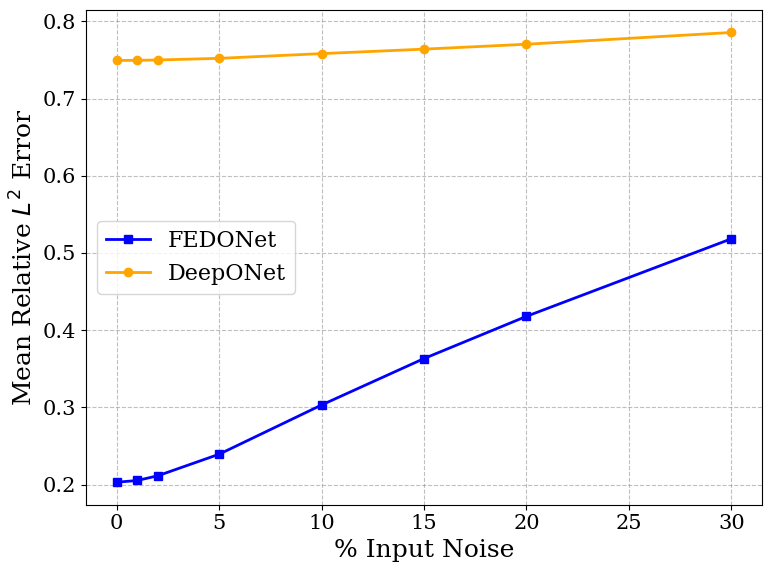

In [54]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def rel_l2_error_batch(true, pred):
    errs = []
    for i in range(true.shape[0]):
        num = np.linalg.norm(true[i] - pred[i])
        den = np.linalg.norm(true[i]) + 1e-12
        errs.append(num / den)
    return np.sum(errs), len(errs)

noise_levels = [0.0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]

fedonet_errors = []
deeponet_errors = []

model.eval()
model_normal.eval()

coords_device = torch.tensor(coords, dtype=torch.float32).to(device)

with torch.no_grad():
    for noise_level in noise_levels:
        fed_sum = 0.0
        deep_sum = 0.0
        total_samples = 0

        for initial_condition, full_solution in test_loader:
            initial_condition = initial_condition.to(device)
            full_solution = full_solution.to(device)

            rms = torch.sqrt(torch.mean(initial_condition**2, dim=1, keepdim=True) + 1e-12)
            noise = torch.randn_like(initial_condition) * (noise_level * rms)
            initial_condition_noisy = initial_condition + noise

            pred_fedonet = model(initial_condition_noisy, coords_device)
            pred_deeponet = model_normal(initial_condition_noisy, coords_device)

            true_np = full_solution.cpu().numpy()
            pred_fedonet_np = pred_fedonet.cpu().numpy()
            pred_deeponet_np = pred_deeponet.cpu().numpy()

            fed_err_sum, n1 = rel_l2_error_batch(true_np, pred_fedonet_np)
            deep_err_sum, n2 = rel_l2_error_batch(true_np, pred_deeponet_np)

            fed_sum += fed_err_sum
            deep_sum += deep_err_sum
            total_samples += n1

        fedonet_errors.append(fed_sum / total_samples)
        deeponet_errors.append(deep_sum / total_samples)

        print(f"Noise = {noise_level:.2f} | FEDONet = {fed_sum/total_samples:.6e} | DeepONet = {deep_sum/total_samples:.6e}")

import matplotlib as mpl

def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})


plt.figure(figsize=(8,6))
plt.plot(np.array(noise_levels)*100, fedonet_errors, color='blue',marker='s', label='FEDONet')
plt.plot(np.array(noise_levels)*100, deeponet_errors, color='orange',marker='o',  label='DeepONet')

plt.xlabel("% Input Noise")
plt.ylabel("Mean Relative $L^2$ Error")
plt.grid(True)
plt.legend(loc='center left')

plt.tight_layout()
plt.show()


Noise = 5.0% | Rel L2 Error = 3.728560e-01
Noise = 10.0% | Rel L2 Error = 4.024271e-01
Noise = 15.0% | Rel L2 Error = 6.180563e-01
Noise = 25.0% | Rel L2 Error = 5.393245e-01


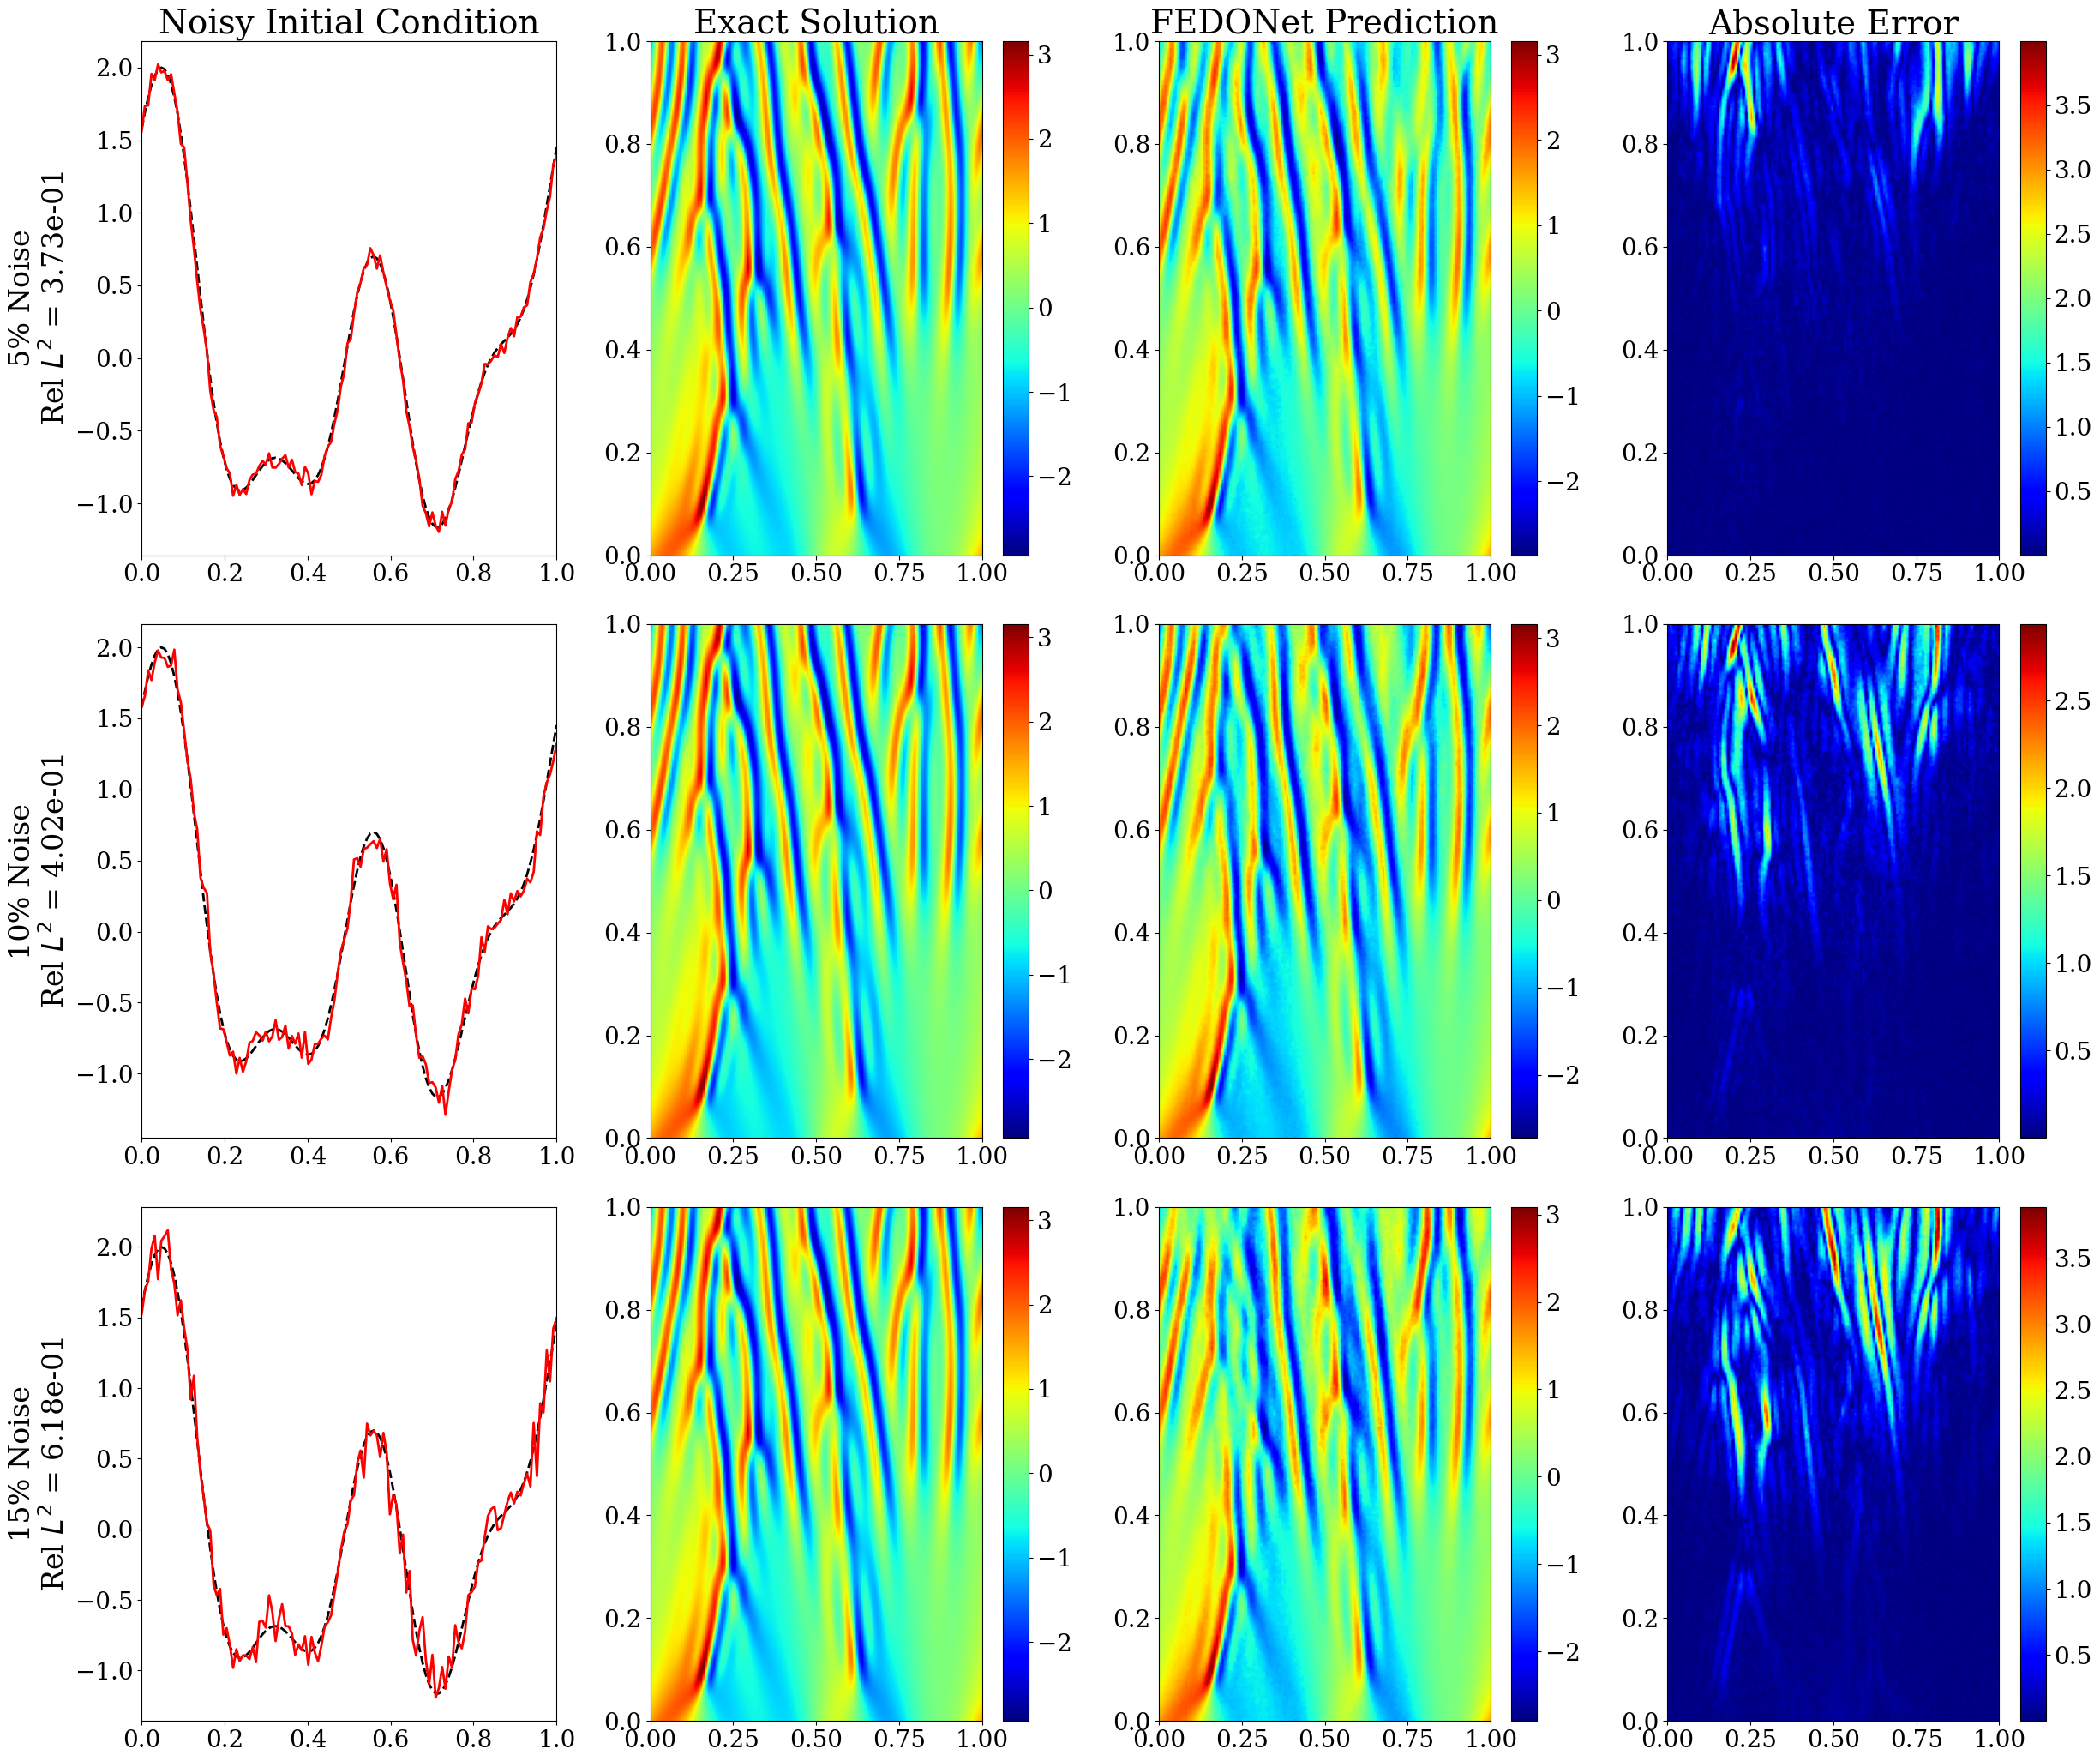

In [95]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# RELATIVE L2 ERROR
# ============================================================
def rel_l2_error(true, pred):
    return np.linalg.norm(true - pred) / (np.linalg.norm(true) + 1e-12)


# ============================================================
# GET ONE SAMPLE
# ============================================================
initial_condition, full_solution = next(iter(test_loader))

initial_condition = initial_condition.to(device)
full_solution = full_solution.to(device)

idx = 2
ic_clean = initial_condition[idx:idx+1]
u_exact = full_solution[idx:idx+1]

# coords to tensor
if isinstance(coords, np.ndarray):
    coords_device = torch.tensor(coords, dtype=torch.float32).to(device)
else:
    coords_device = coords.to(device)

ic_clean_np = ic_clean.squeeze().cpu().numpy()
u_exact_np = u_exact.squeeze().cpu().numpy()


# ============================================================
# NOISE LEVELS
# ============================================================
noise_levels = [ 0.05, 0.10, 0.15, 0.25]

ic_list = []
pred_list = []
err_list = []
rel_errors = []

model.eval()

# ============================================================
# GENERATE PREDICTIONS
# ============================================================
with torch.no_grad():

    for noise_level in noise_levels:

        rms = torch.sqrt(torch.mean(ic_clean**2, dim=1, keepdim=True) + 1e-12)
        noise = torch.randn_like(ic_clean) * (noise_level * rms)

        ic_noisy = ic_clean + noise

        pred = model(ic_noisy, coords_device)

        abs_err = torch.abs(pred - u_exact)

        ic_noisy_np = ic_noisy.squeeze().cpu().numpy()
        pred_np = pred.squeeze().cpu().numpy()
        abs_err_np = abs_err.squeeze().cpu().numpy()

        rel_l2 = rel_l2_error(u_exact_np, pred_np)

        rel_errors.append(rel_l2)

        print(f"Noise = {noise_level*100:.1f}% | Rel L2 Error = {rel_l2:.6e}")

        ic_list.append(ic_noisy_np)
        pred_list.append(pred_np)
        err_list.append(abs_err_np)


# ============================================================
# TITLES
# ============================================================
titles = [
    f"{int(noise_levels[j]*100)}% Noise\nRel $L^2$ = {rel_errors[j]:.2e}"
    for j in range(4)
]


# ============================================================
# PLOT
# ============================================================
import matplotlib as mpl

def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 22
})

fig, axes = plt.subplots(3, 4, figsize=(25, 21))

# ----------------------------
# ROW 1: INITIAL CONDITIONS
# ----------------------------
for j in range(3):

    ax = axes[j, 0]

    ax.plot(np.linspace(0,1,len(ic_clean_np)), ic_clean_np, color='k',linestyle='--')
    ax.plot(np.linspace(0,1,len(ic_list[j])), ic_list[j],color='r')

    ax.set_xlim(0,1)
    

    if j==0:
        ax.set_title("Noisy Initial Condition")
    ax.set_ylabel(titles[j])


# ----------------------------
# ROW 2: EXACT SOLUTION
# ----------------------------
for j in range(3):

    ax = axes[j, 1]

    im = ax.imshow(
        u_exact_np.T,
        extent=[0,1,0,1],
        origin='lower',
        aspect='auto',
        cmap='jet'
    )

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    if j==0:
        ax.set_title("Exact Solution")
    # ax.set_ylabel("t")

    plt.colorbar(im, ax=ax)


# ----------------------------
# ROW 3: FEDONET PREDICTION
# ----------------------------
for j in range(3):

    ax = axes[j, 2]

    im = ax.imshow(
        pred_list[j].T,
        extent=[0,1,0,1],
        origin='lower',
        aspect='auto',
        cmap='jet'
    )

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    if j==0:
        ax.set_title("FEDONet Prediction")
    # ax.set_ylabel("t")

    plt.colorbar(im, ax=ax)


# ----------------------------
# ROW 4: ERROR
# ----------------------------
for j in range(3):

    ax = axes[j, 3]

    im = ax.imshow(
        err_list[j].T,
        extent=[0,1,0,1],
        origin='lower',
        aspect='auto',
        cmap='jet'
    )

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

    if j==0:
        ax.set_title("Absolute Error")
    # ax.set_ylabel("t")

    plt.colorbar(im, ax=ax)


# ============================================================
# ROW LABELS
# ============================================================
# axes[0,0].text(-0.4,0.5,'Noisy Initial Condition', transform=axes[0,0].transAxes, rotation=90, va='center')
# axes[1,0].text(-0.4,0.5,'Exact Solution', transform=axes[1,0].transAxes, rotation=90, va='center')
# axes[2,0].text(-0.4,0.5,'FEDONet Prediction', transform=axes[2,0].transAxes, rotation=90, va='center')
# axes[3,0].text(-0.4,0.5,'Absolute Error', transform=axes[3,0].transAxes, rotation=90, va='center')

plt.tight_layout()
plt.show()
